Note: __yfinance can be unstable/unreliable from time to time__ when it comes to downloading fundamental data with the ticker object. In particular, __ticker.get_info()__ can be flawed.

__Action required__: Check for the __latest yfinance versions__ and update with the following command (Anaconda Prompt / Terminal):

pip install yfinance --upgrade

In the following, I have added an __alternative Yahoo Finance API Wrapper__, __yahooquery__

__Action required: Please install yahooquery with the following command (Anaconda Prompt / Terminal):__

pip install yahooquery --upgrade

Note: 
- Please make sure you have installed the __latest__ yahooquery version (if not, please upgrade). 

__Update December 2023__: Sometimes yfinance is more stable/reliable and sometimes yahooquery is more stable/reliable. Most recently, yfinance seemed to be better. In any case, __please make sure you have the latest versions installed!__

# Keystone Project - The Dow Jones Index Constituents

__Assignment / Goal:__

1. Load __historical price and volume data__ for all __30 stocks/constituents__ of the Dow Jones Industrial Average (__DJIA__) stock index.

2. Load and save other stock information like __Exchange, Industry, Price Performance, Dividend Yield, Price-to-Book ratio and Forward P/E ratio__.

3. __Compare/sort stocks__ by Price Performance, Dividend Yield, Price-to-Book ratio and Forward P/E ratio.

What is the Dow Jones Industrial Average (DJIA)?

__"The Dow Jones Industrial Average (DJIA), Dow Jones, or simply the Dow, is a stock market index of 30 prominent companies listed on stock exchanges in the United States.[...]"__ (Wikipedia) https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average

(hint: you can load tables from a website with pd.read_html(url))

## Loading the DJIA 30 Constituents from the Web

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

%config InlineBackend.figure_format = 'retina'

In [4]:
import requests

In [5]:
url = "https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average"
url

'https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average'

In [6]:
requests.get(url)

<Response [403]>

In [7]:
requests.get(url).status_code

403

In [8]:
requests.get(url).text

'Please set a user-agent and respect our robot policy https://w.wiki/4wJS. See also https://phabricator.wikimedia.org/T400119.\n'

In [9]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

In [10]:
response = requests.get(url, headers = headers)

In [11]:
response.status_code

200

In [12]:
response.text

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Dow Jones Industrial Average - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-p

In [13]:
html_content = response.text
html_content

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Dow Jones Industrial Average - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-p

In [14]:
pd.read_html(html_content)[0]

/tmp/ipykernel_913/4220502734.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  pd.read_html(html_content)[0]


,0,1
0,Historical logarithmic graph of the DJIA from ...,Historical logarithmic graph of the DJIA from ...
1,Foundation,"February 16, 1885; 141 years ago (as DJA)[1] M..."
2,Operator,S&P Dow Jones Indices
3,Exchanges,New York Stock ExchangeNasdaq
4,Trading symbol,^DJI$INDU.DJIDJIA
5,Constituents,30
6,Type,Large cap
7,Market cap,"US$22.9 trillion (as of October 31, 2025)[3]"
8,Weighting method,Price-weighted index
9,Website,www.spglobal.com/spdji/en/


In [15]:
pd.read_html(html_content)[1]

/tmp/ipykernel_913/1035422647.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  pd.read_html(html_content)[1]


,Company,Exchange,Symbol,Sector,Date added,Notes,Index weighting
0,3M,NYSE,MMM,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,1.85%
1,Alphabet,NASDAQ,GOOGL,Communication Services,2026-06-29,NaN,4.03%
2,American Express,NYSE,AXP,Financials,1982-08-30,NaN,3.88%
3,Amgen,NASDAQ,AMGN,Health Care,2020-08-31,NaN,4.11%
4,Amazon,NASDAQ,AMZN,Consumer Discretionary,2024-02-26,NaN,2.74%
5,Apple,NASDAQ,AAPL,Information Technology,2015-03-19,NaN,3.21%
6,Boeing,NYSE,BA,Industrials,1987-03-12,NaN,2.45%
7,Caterpillar,NYSE,CAT,Industrials,1991-05-06,NaN,11.77%
8,Chevron,NYSE,CVX,Energy,2008-02-19,Also 1930-07-18 to 1999-11-01,1.92%
9,Cisco,NASDAQ,CSCO,Information Technology,2009-06-08,NaN,1.34%


In [16]:
from io import StringIO 

In [17]:
pd.read_html(StringIO(html_content))[0]

,0,1
0,Historical logarithmic graph of the DJIA from ...,Historical logarithmic graph of the DJIA from ...
1,Foundation,"February 16, 1885; 141 years ago (as DJA)[1] M..."
2,Operator,S&P Dow Jones Indices
3,Exchanges,New York Stock ExchangeNasdaq
4,Trading symbol,^DJI$INDU.DJIDJIA
5,Constituents,30
6,Type,Large cap
7,Market cap,"US$22.9 trillion (as of October 31, 2025)[3]"
8,Weighting method,Price-weighted index
9,Website,www.spglobal.com/spdji/en/


In [18]:
pd.read_html(StringIO(html_content))[1]

,Company,Exchange,Symbol,Sector,Date added,Notes,Index weighting
0,3M,NYSE,MMM,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,1.85%
1,Alphabet,NASDAQ,GOOGL,Communication Services,2026-06-29,NaN,4.03%
2,American Express,NYSE,AXP,Financials,1982-08-30,NaN,3.88%
3,Amgen,NASDAQ,AMGN,Health Care,2020-08-31,NaN,4.11%
4,Amazon,NASDAQ,AMZN,Consumer Discretionary,2024-02-26,NaN,2.74%
5,Apple,NASDAQ,AAPL,Information Technology,2015-03-19,NaN,3.21%
6,Boeing,NYSE,BA,Industrials,1987-03-12,NaN,2.45%
7,Caterpillar,NYSE,CAT,Industrials,1991-05-06,NaN,11.77%
8,Chevron,NYSE,CVX,Energy,2008-02-19,Also 1930-07-18 to 1999-11-01,1.92%
9,Cisco,NASDAQ,CSCO,Information Technology,2009-06-08,NaN,1.34%


In [19]:
pd.read_html(StringIO(html_content))[2]

,0,1
0,Companies Combined percentage 1st to 5th 36.47...,Companies Combined percentage Top 5 36.47% Top...
1,Companies,Combined percentage
2,1st to 5th,36.47%
3,6th to 10th,19.72%
4,11th to 15th,16.95%
5,16th to 20th,12.94%
6,21st to 25th,8.73%
7,26th to 30th,5.18%
8,Companies,Combined percentage
9,Top 5,36.47%


In [20]:
df_DOW_JONES = pd.read_html(StringIO(html_content))[1]
df_DOW_JONES

,Company,Exchange,Symbol,Sector,Date added,Notes,Index weighting
0,3M,NYSE,MMM,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,1.85%
1,Alphabet,NASDAQ,GOOGL,Communication Services,2026-06-29,NaN,4.03%
2,American Express,NYSE,AXP,Financials,1982-08-30,NaN,3.88%
3,Amgen,NASDAQ,AMGN,Health Care,2020-08-31,NaN,4.11%
4,Amazon,NASDAQ,AMZN,Consumer Discretionary,2024-02-26,NaN,2.74%
5,Apple,NASDAQ,AAPL,Information Technology,2015-03-19,NaN,3.21%
6,Boeing,NYSE,BA,Industrials,1987-03-12,NaN,2.45%
7,Caterpillar,NYSE,CAT,Industrials,1991-05-06,NaN,11.77%
8,Chevron,NYSE,CVX,Energy,2008-02-19,Also 1930-07-18 to 1999-11-01,1.92%
9,Cisco,NASDAQ,CSCO,Information Technology,2009-06-08,NaN,1.34%


In [21]:
df_DOW_JONES.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Company          30 non-null     object
 1   Exchange         30 non-null     object
 2   Symbol           30 non-null     object
 3   Sector           30 non-null     object
 4   Date added       30 non-null     object
 5   Notes            5 non-null      object
 6   Index weighting  30 non-null     object
dtypes: object(7)
memory usage: 1.8+ KB


In [22]:
df_DOW_JONES.rename(columns = {"Date added":"Date_Added"}, inplace = True)
df_DOW_JONES.rename(columns = {"Index weighting":"Weights"}, inplace = True)

In [ ]:
df_DOW_JONES.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Company     30 non-null     object
 1   Exchange    30 non-null     object
 2   Symbol      30 non-null     object
 3   Sector      30 non-null     object
 4   Date_Added  30 non-null     object
 5   Notes       5 non-null      object
 6   Weights     30 non-null     object
dtypes: object(7)
memory usage: 1.8+ KB


In [ ]:
df_DOW_JONES.Date_Added = pd.to_datetime(df_DOW_JONES.Date_Added)

In [25]:
df_DOW_JONES.Weights = pd.to_numeric(df_DOW_JONES.Weights.str.replace("%", ""))

In [26]:
df_DOW_JONES

,Company,Exchange,Symbol,Sector,Date_Added,Notes,Weights
0,3M,NYSE,MMM,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,1.85
1,Alphabet,NASDAQ,GOOGL,Communication Services,2026-06-29,NaN,4.03
2,American Express,NYSE,AXP,Financials,1982-08-30,NaN,3.88
3,Amgen,NASDAQ,AMGN,Health Care,2020-08-31,NaN,4.11
4,Amazon,NASDAQ,AMZN,Consumer Discretionary,2024-02-26,NaN,2.74
5,Apple,NASDAQ,AAPL,Information Technology,2015-03-19,NaN,3.21
6,Boeing,NYSE,BA,Industrials,1987-03-12,NaN,2.45
7,Caterpillar,NYSE,CAT,Industrials,1991-05-06,NaN,11.77
8,Chevron,NYSE,CVX,Energy,2008-02-19,Also 1930-07-18 to 1999-11-01,1.92
9,Cisco,NASDAQ,CSCO,Information Technology,2009-06-08,NaN,1.34


In [27]:
df_DOW_JONES.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Company     30 non-null     object        
 1   Exchange    30 non-null     object        
 2   Symbol      30 non-null     object        
 3   Sector      30 non-null     object        
 4   Date_Added  30 non-null     datetime64[ns]
 5   Notes       5 non-null      object        
 6   Weights     30 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 1.8+ KB


In [28]:
df_DOW_JONES.Weights.sum()

np.float64(100.0)

In [29]:
df_DOW_JONES.drop(columns = "Notes", inplace = True)

In [30]:
df_DOW_JONES.set_index("Symbol", inplace = True)

In [31]:
df_DOW_JONES

,Company,Exchange,Sector,Date_Added,Weights
Symbol,,,,,
MMM,3M,NYSE,Industrials,1976-08-09,1.85
GOOGL,Alphabet,NASDAQ,Communication Services,2026-06-29,4.03
AXP,American Express,NYSE,Financials,1982-08-30,3.88
AMGN,Amgen,NASDAQ,Health Care,2020-08-31,4.11
AMZN,Amazon,NASDAQ,Consumer Discretionary,2024-02-26,2.74
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.21
BA,Boeing,NYSE,Industrials,1987-03-12,2.45
CAT,Caterpillar,NYSE,Industrials,1991-05-06,11.77
CVX,Chevron,NYSE,Energy,2008-02-19,1.92


In [32]:
symbols = df_DOW_JONES.index.to_list()
symbols

['MMM',
 'GOOGL',
 'AXP',
 'AMGN',
 'AMZN',
 'AAPL',
 'BA',
 'CAT',
 'CVX',
 'CSCO',
 'KO',
 'DIS',
 'GS',
 'HD',
 'HON',
 'IBM',
 'JNJ',
 'JPM',
 'MCD',
 'MRK',
 'MSFT',
 'NKE',
 'NVDA',
 'PG',
 'CRM',
 'SHW',
 'TRV',
 'UNH',
 'V',
 'WMT']

In [33]:
import matplotlib

In [34]:
df_DOW_JONES.sort_values("Date_Added", ascending = False)

,Company,Exchange,Sector,Date_Added,Weights
Symbol,,,,,
GOOGL,Alphabet,NASDAQ,Communication Services,2026-06-29,4.03
SHW,Sherwin-Williams,NYSE,Materials,2024-11-08,3.92
NVDA,Nvidia,NASDAQ,Information Technology,2024-11-08,2.22
AMZN,Amazon,NASDAQ,Consumer Discretionary,2024-02-26,2.74
CRM,Salesforce,NYSE,Information Technology,2020-08-31,1.80
AMGN,Amgen,NASDAQ,Health Care,2020-08-31,4.11
HON,Honeywell Technologies,NASDAQ,Industrials,2020-08-31,2.59
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.21
V,Visa,NYSE,Financials,2013-09-23,3.89


In [35]:
last_update = df_DOW_JONES["Date_Added"].max()
last_update

Timestamp('2026-06-29 00:00:00')

## Load Historical Price/Volume Data (Time Series)

In [36]:
symbols

['MMM',
 'GOOGL',
 'AXP',
 'AMGN',
 'AMZN',
 'AAPL',
 'BA',
 'CAT',
 'CVX',
 'CSCO',
 'KO',
 'DIS',
 'GS',
 'HD',
 'HON',
 'IBM',
 'JNJ',
 'JPM',
 'MCD',
 'MRK',
 'MSFT',
 'NKE',
 'NVDA',
 'PG',
 'CRM',
 'SHW',
 'TRV',
 'UNH',
 'V',
 'WMT']

In [37]:
ts = yf.download(tickers = symbols, start = last_update , multi_level_index = False)
ts

/tmp/ipykernel_913/3653149399.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ts = yf.download(tickers = symbols, start = last_update , multi_level_index = False)
[*********************100%***********************]  30 of 30 completed


Price       Close                                                           \
Ticker       AAPL   AMGN   AMZN    AXP     BA     CAT    CRM   CSCO    CVX   
Date                                                                         
2026-06-29 281.74 360.55 240.14 339.95 214.69 1033.19 157.93 117.26 168.47   
2026-06-30 289.36 362.12 238.34 337.33 216.47 1064.90 156.66 117.02 165.76   
2026-07-01 294.38 361.33 241.70 347.05 218.58  991.41 163.23 116.57 165.69   
2026-07-02 308.63 374.15 242.67 351.96 226.49  963.53 166.11 112.27 169.20   
2026-07-06 312.66 366.44 244.16 356.03 234.54  969.92 165.65 113.98 168.10   
2026-07-07 310.66 368.10 245.98 349.58 231.68  940.12 169.52 111.79 174.01   
2026-07-08 313.39 367.99 243.62 336.39 224.95  948.08 166.58 113.82 175.97   
2026-07-09 316.22 363.62 247.04 346.72 223.11  938.39 162.50 118.31 174.05   
2026-07-10 315.32 363.39 245.34 350.58 222.28  952.41 163.32 121.31 176.40   
2026-07-13 317.31 360.45 247.31 354.43 215.51  931.47 171.22 119.25 182.20   

Price             ...    Volume                                           \
Ticker       DIS  ...       MRK      MSFT       NKE       NVDA        PG   
Date              ...                                                      
2026-06-29 97.88  ...   9584600  51229900  27824700  148835700  10387700   
2026-06-30 96.25  ...  11837200  44945700  73891500  166476700   9353800   
2026-07-01 95.71  ...  10761500  48065800  80185700  146147600   9571700   
2026-07-02 99.50  ...   7832200  42128900  34233400  142068700   9256000   
2026-07-06 97.41  ...   9499300  34224500  21979100  108999000   8323100   
2026-07-07 97.48  ...  10174300  29297500  17784900  124154600   8061400   
2026-07-08 96.70  ...   7910200  25908300  21101500  147419100  14272300   
2026-07-09 96.17  ...   6975500  31083200  19647000  132037400   7748000   
2026-07-10 95.62  ...   8388400  24644600  23313500  148421000  12473000   
2026-07-13 96.00  ...   4954909  27505099  11414916  113202886   6549566   

Price                                                      
Ticker          SHW      TRV      UNH         V       WMT  
Date                                                       
2026-06-29  3913300  1314600  5167400  11710900  20367000  
2026-06-30  2455900  1730200  5779800   7957900  23034000  
2026-07-01  2485600  1365800  4985900  13025900  40391400  
2026-07-02  2078700  1459200  3928800   9814800  29512200  
2026-07-06  1688000  1513900  6379000  11623800  29523300  
2026-07-07  2459800  1525600  5800500   7332500  19941400  
2026-07-08  2232200  1688500  3859200  10215200  19892000  
2026-07-09  1314400  1368000  5566000   6606300  20464500  
2026-07-10  1125200  1074500  3798600   4702800  12461700  
2026-07-13  2021797  1378716  3855804   9959731  15880294  

[10 rows x 150 columns]

In [38]:
ts.columns[0]

('Close', 'AAPL')

In [39]:
set([col[0] for col in ts.columns])

{'Close', 'High', 'Low', 'Open', 'Volume'}

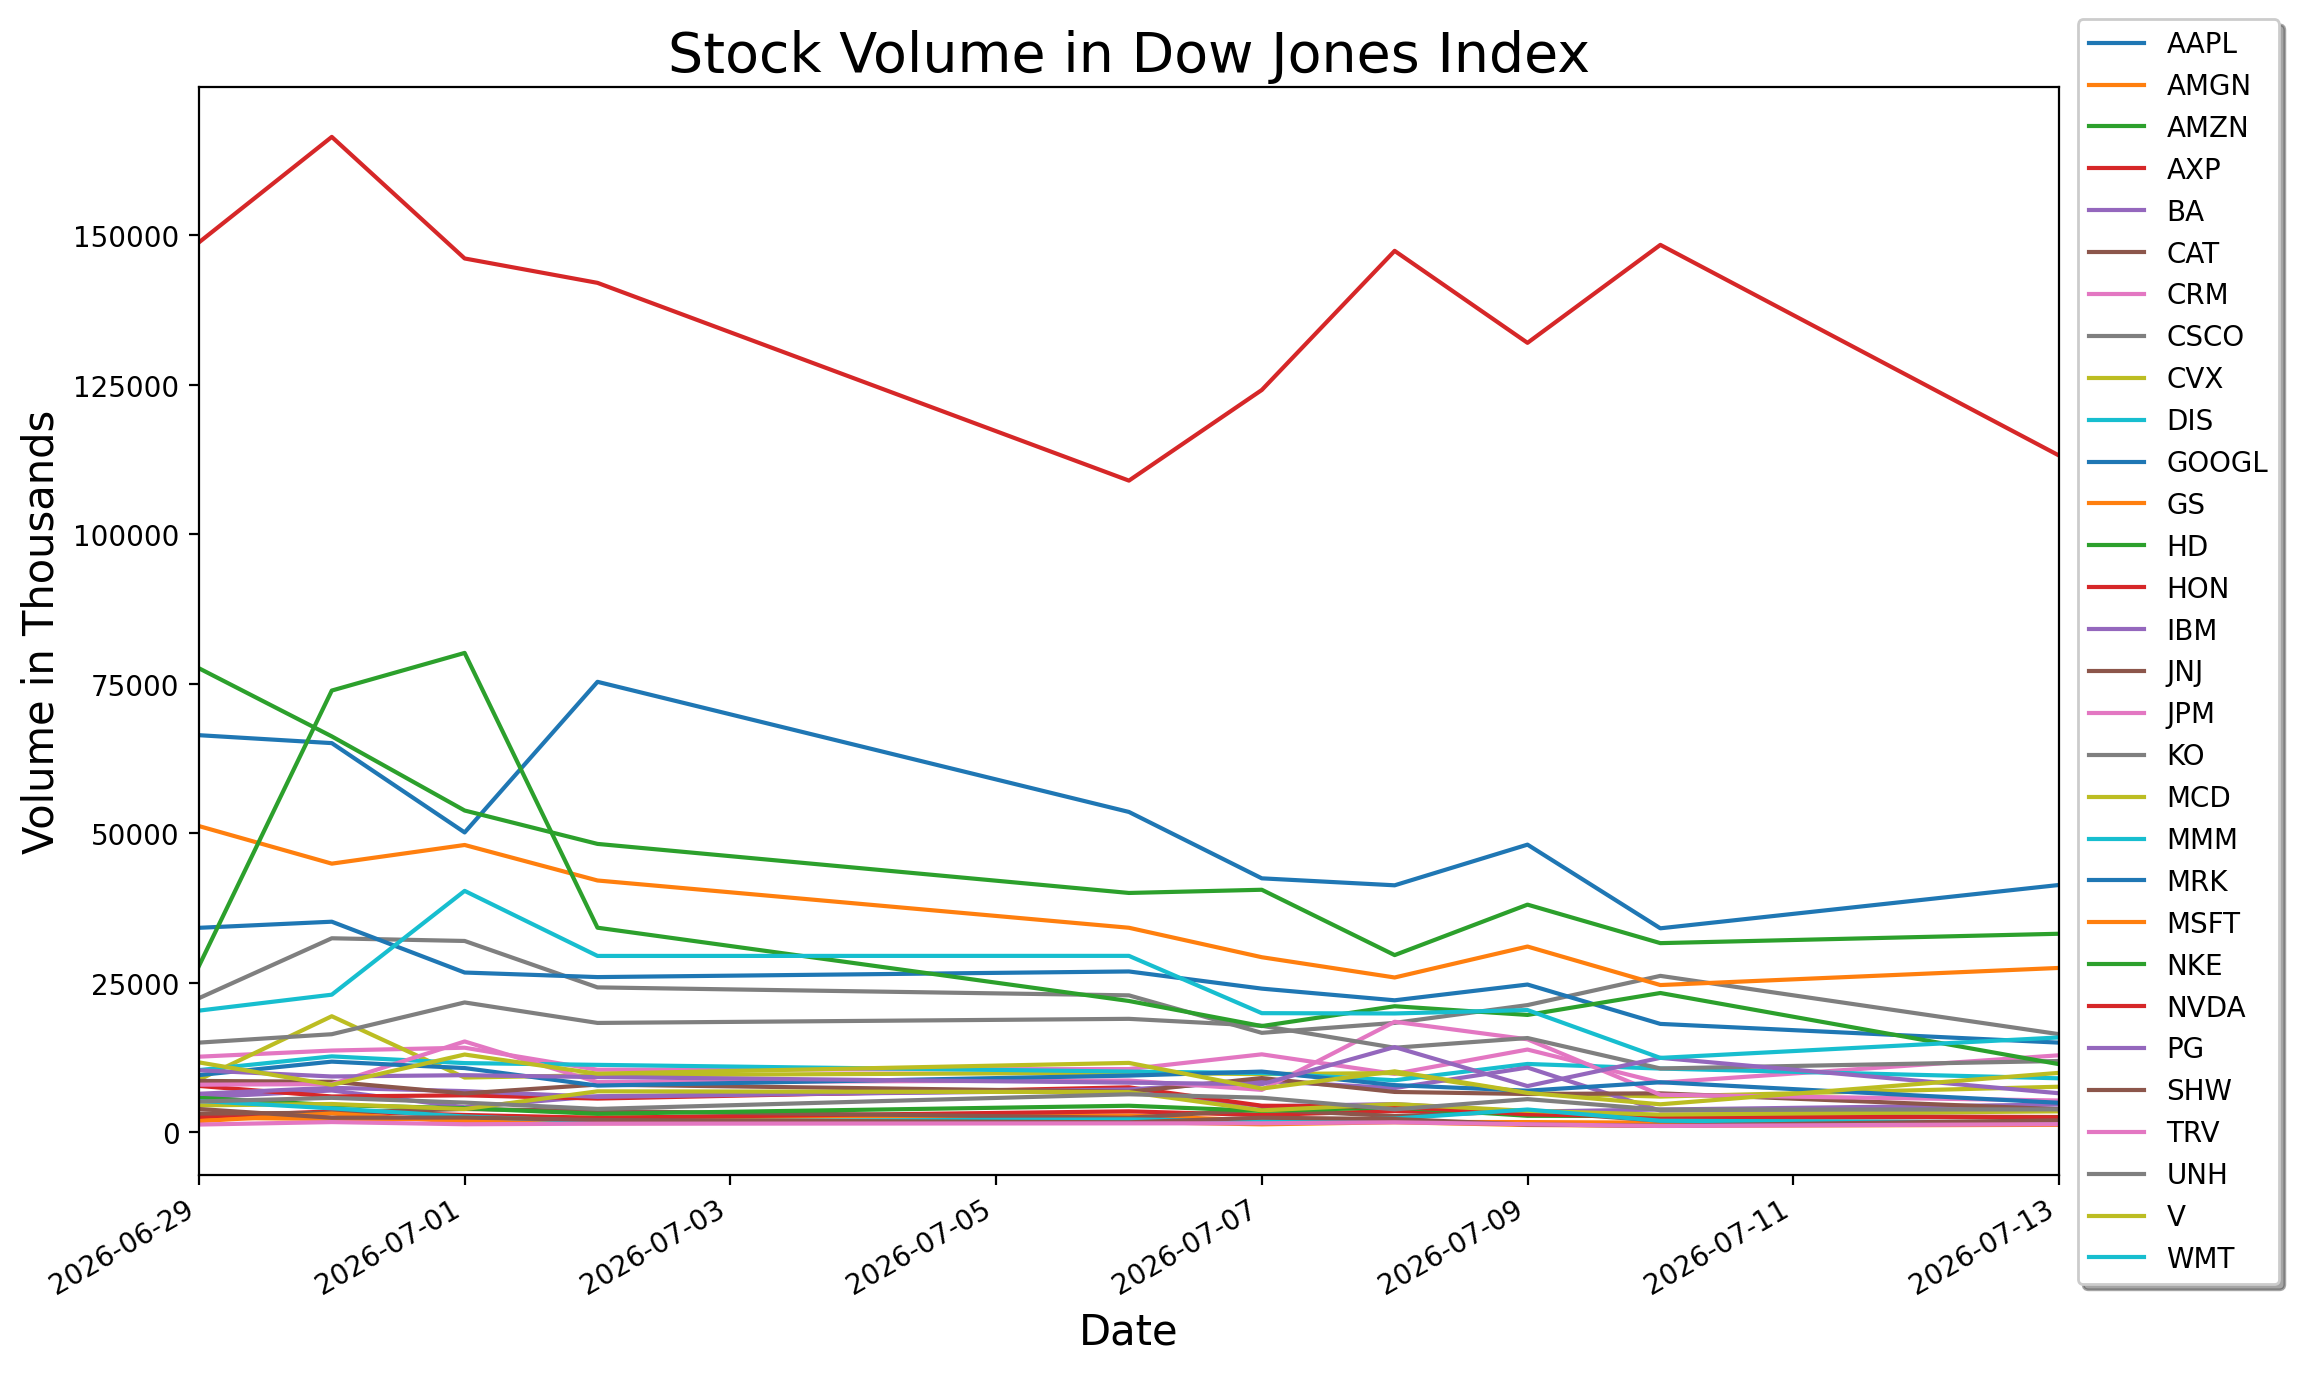

In [40]:
ts.Volume.div(10**3).plot(figsize = (12, 8))
plt.title("Stock Volume in Dow Jones Index", fontsize = 20)
plt.xlabel("Date", fontsize = 15)
plt.ylabel("Volume in Thousands", fontsize = 15)
plt.legend(loc =(1.01 , -0.1) , fancybox = True, shadow = True)
plt.autoscale(axis = "x", tight = True)

In [41]:
ts.isna().sum()

Price   Ticker
Close   AAPL      0
        AMGN      0
        AMZN      0
        AXP       0
        BA        0
                 ..
Volume  SHW       0
        TRV       0
        UNH       0
        V         0
        WMT       0
Length: 150, dtype: int64

In [42]:
ts.Close

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-29,281.74,360.55,240.14,339.95,214.69,1033.19,157.93,117.26,168.47,97.88,...,129.38,368.57,41.48,194.97,148.45,344.30,331.88,419.82,341.65,114.60
2026-06-30,289.36,362.12,238.34,337.33,216.47,1064.90,156.66,117.02,165.76,96.25,...,128.50,373.02,41.05,200.09,146.64,344.32,330.12,415.63,343.09,113.26
2026-07-01,294.38,361.33,241.70,347.05,218.58,991.41,163.23,116.57,165.69,95.71,...,125.37,384.28,43.06,197.58,147.43,346.05,334.62,426.54,351.08,108.82
2026-07-02,308.63,374.15,242.67,351.96,226.49,963.53,166.11,112.27,169.20,99.50,...,129.56,390.49,44.09,194.83,151.41,352.48,342.31,425.36,362.13,111.84
2026-07-06,312.66,366.44,244.16,356.03,234.54,969.92,165.65,113.98,168.10,97.41,...,126.78,386.74,43.34,195.55,149.31,349.13,339.17,417.99,357.25,110.65
2026-07-07,310.66,368.10,245.98,349.58,231.68,940.12,169.52,111.79,174.01,97.48,...,128.86,388.84,43.21,196.93,152.75,342.26,343.73,428.19,352.20,111.54
2026-07-08,313.39,367.99,243.62,336.39,224.95,948.08,166.58,113.82,175.97,96.70,...,125.99,383.34,42.89,204.12,148.40,330.57,337.94,425.60,347.53,113.10
2026-07-09,316.22,363.62,247.04,346.72,223.11,938.39,162.50,118.31,174.05,96.17,...,125.07,384.36,42.78,202.78,146.85,332.03,337.48,431.68,348.20,112.21
2026-07-10,315.32,363.39,245.34,350.58,222.28,952.41,163.32,121.31,176.40,95.62,...,123.54,385.10,44.37,210.96,147.04,333.99,338.92,424.62,348.97,113.90


In [43]:
last_update = ts.Close.iloc[-1]
last_update

,2026-07-13
Ticker,
AAPL,317.31
AMGN,360.45
AMZN,247.31
AXP,354.43
BA,215.51
CAT,931.47
CRM,171.22
CSCO,119.25
CVX,182.20


In [44]:
first_update = ts.Close.iloc[0]
first_update

,2026-06-29
Ticker,
AAPL,281.74
AMGN,360.55
AMZN,240.14
AXP,339.95
BA,214.69
CAT,1033.19
CRM,157.93
CSCO,117.26
CVX,168.47


In [45]:
perf = (last_update/first_update) - 1
perf

,0
Ticker,
AAPL,0.13
AMGN,-0.00
AMZN,0.03
AXP,0.04
BA,0.00
CAT,-0.10
CRM,0.08
CSCO,0.02
CVX,0.08


In [46]:
perf = perf.sort_values(ascending = False)
perf = perf * 100
perf

,0
Ticker,
AAPL,12.63
CRM,8.42
CVX,8.15
MSFT,6.08
NKE,5.50
V,4.71
IBM,4.40
NVDA,4.39
AXP,4.26


In [47]:
df_DOW_JONES["Performance"] = perf

In [48]:
df_DOW_JONES

,Company,Exchange,Sector,Date_Added,Weights,Performance
Symbol,,,,,,
MMM,3M,NYSE,Industrials,1976-08-09,1.85,-2.91
GOOGL,Alphabet,NASDAQ,Communication Services,2026-06-29,4.03,-0.32
AXP,American Express,NYSE,Financials,1982-08-30,3.88,4.26
AMGN,Amgen,NASDAQ,Health Care,2020-08-31,4.11,-0.03
AMZN,Amazon,NASDAQ,Consumer Discretionary,2024-02-26,2.74,2.99
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.21,12.63
BA,Boeing,NYSE,Industrials,1987-03-12,2.45,0.38
CAT,Caterpillar,NYSE,Industrials,1991-05-06,11.77,-9.85
CVX,Chevron,NYSE,Energy,2008-02-19,1.92,8.15


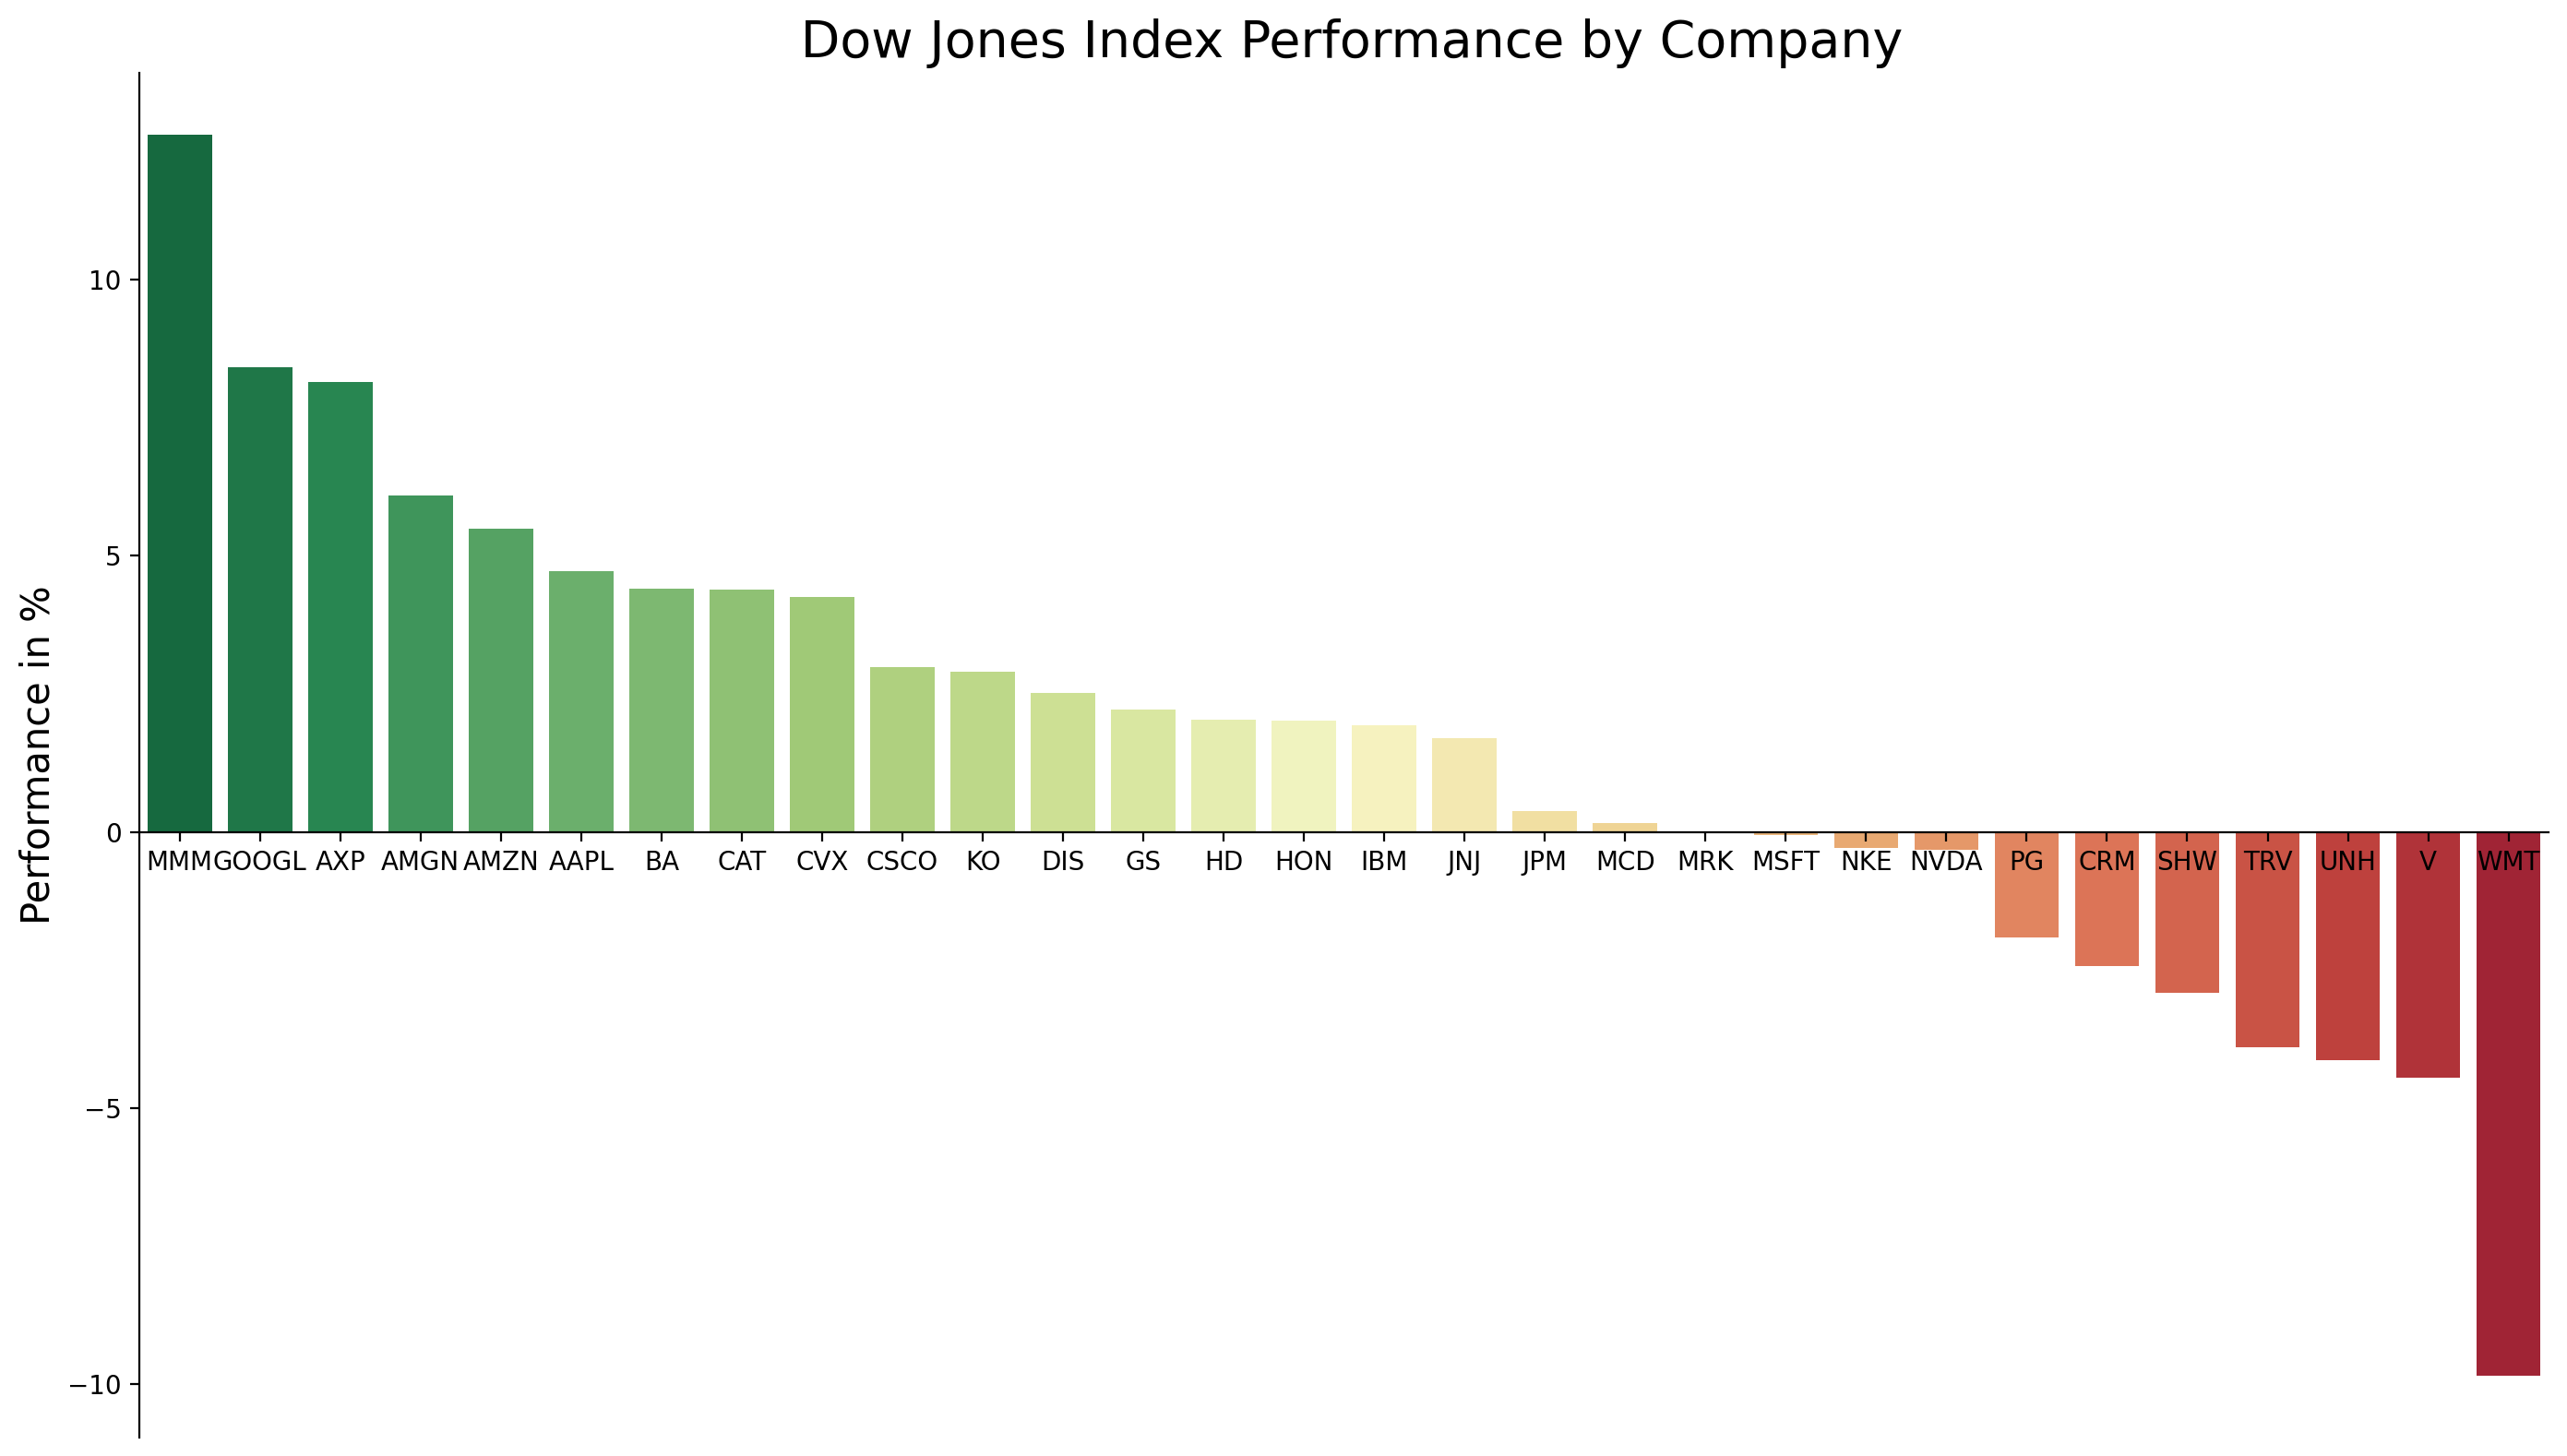

In [49]:
fig , ax = plt.subplots(figsize = (14, 8))
sns.barplot(data = df_DOW_JONES.sort_values(by = ["Performance"], ascending = False), 
            x = df_DOW_JONES.index, 
            y = "Performance" ,
            hue = df_DOW_JONES.index, 
            palette = "RdYlGn_r")

ax.set_ylabel("Performance in %", fontsize = 15)
ax.set_xlabel("", fontsize = 15)
ax.set_title(" Dow Jones Index Performance by Company", fontsize = 20)

ax.spines["bottom"].set_position(('data' , 0))
plt.tight_layout()
sns.despine()

In [ ]:
sorted_df_DOW_JONES = df_DOW_JONES.sort_values(by = ["Performance"], ascending = False)
sorted_df_DOW_JONES

,Company,Exchange,Sector,Date_Added,Weights,Performance
Symbol,,,,,,
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.21,12.63
CRM,Salesforce,NYSE,Information Technology,2020-08-31,1.80,8.42
CVX,Chevron,NYSE,Energy,2008-02-19,1.92,8.15
MSFT,Microsoft,NASDAQ,Information Technology,1999-11-01,4.20,6.08
NKE,Nike,NYSE,Consumer Discretionary,2013-09-23,0.47,5.50
V,Visa,NYSE,Financials,2013-09-23,3.89,4.71
IBM,IBM,NYSE,Information Technology,1979-06-29,3.17,4.40
NVDA,Nvidia,NASDAQ,Information Technology,2024-11-08,2.22,4.39
AXP,American Express,NYSE,Financials,1982-08-30,3.88,4.26


In [51]:
sorted_df_DOW_JONES.groupby(["Sector"]).agg({"Performance": "mean"})

,Performance
Sector,
Communication Services,-1.12
Consumer Discretionary,1.65
Consumer Staples,0.68
Energy,8.15
Financials,3.28
Health Care,-0.56
Industrials,-3.70
Information Technology,6.27
Materials,-4.45


In [52]:
sorted_df_DOW_JONES.groupby(["Sector"]).agg({"Performance": "mean"}).size

9

In [53]:
n_colors=sorted_df_DOW_JONES["Sector"].nunique()
n_colors

9

In [54]:
color = sns.color_palette("RdYlGn_r" , n_colors = 9)
color

[(0.09996155324875051, 0.5923875432525952, 0.3118031526336025),
 (0.4000000000000002, 0.7411764705882354, 0.38823529411764707),
 (0.6460592079969244, 0.8488273740868897, 0.41514801999231066),
 (0.8509803921568628, 0.9372549019607844, 0.5450980392156864),
 (0.9999231064975009, 0.9976163014225298, 0.7450211457131872),
 (0.996078431372549, 0.8784313725490196, 0.5450980392156862),
 (0.9914648212226067, 0.6773548635140331, 0.3780853517877739),
 (0.9568627450980393, 0.42745098039215684, 0.2627450980392157),
 (0.8392925797770089, 0.1845444059976932, 0.1528642829680892)]

In [55]:
sorted_df_DOW_JONES["Performance"].index

Index(['AAPL', 'CRM', 'CVX', 'MSFT', 'NKE', 'V', 'IBM', 'NVDA', 'AXP', 'AMZN',
       'TRV', 'GS', 'UNH', 'MCD', 'JPM', 'KO', 'CSCO', 'BA', 'WMT', 'AMGN',
       'PG', 'JNJ', 'GOOGL', 'DIS', 'HON', 'MMM', 'HD', 'MRK', 'SHW', 'CAT'],
      dtype='object', name='Symbol')

In [56]:
colors2 = ["green" if x> 0 else "red" for x in sorted_df_DOW_JONES.groupby(["Sector"]).agg({"Performance": "mean"}).Performance]
colors2

['red', 'green', 'green', 'green', 'green', 'red', 'red', 'green', 'red']

In [57]:
type(sorted_df_DOW_JONES.groupby(["Sector"]).agg({"Performance": "mean"}))#.Performance

pandas.core.frame.DataFrame

/tmp/ipykernel_913/221164662.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)


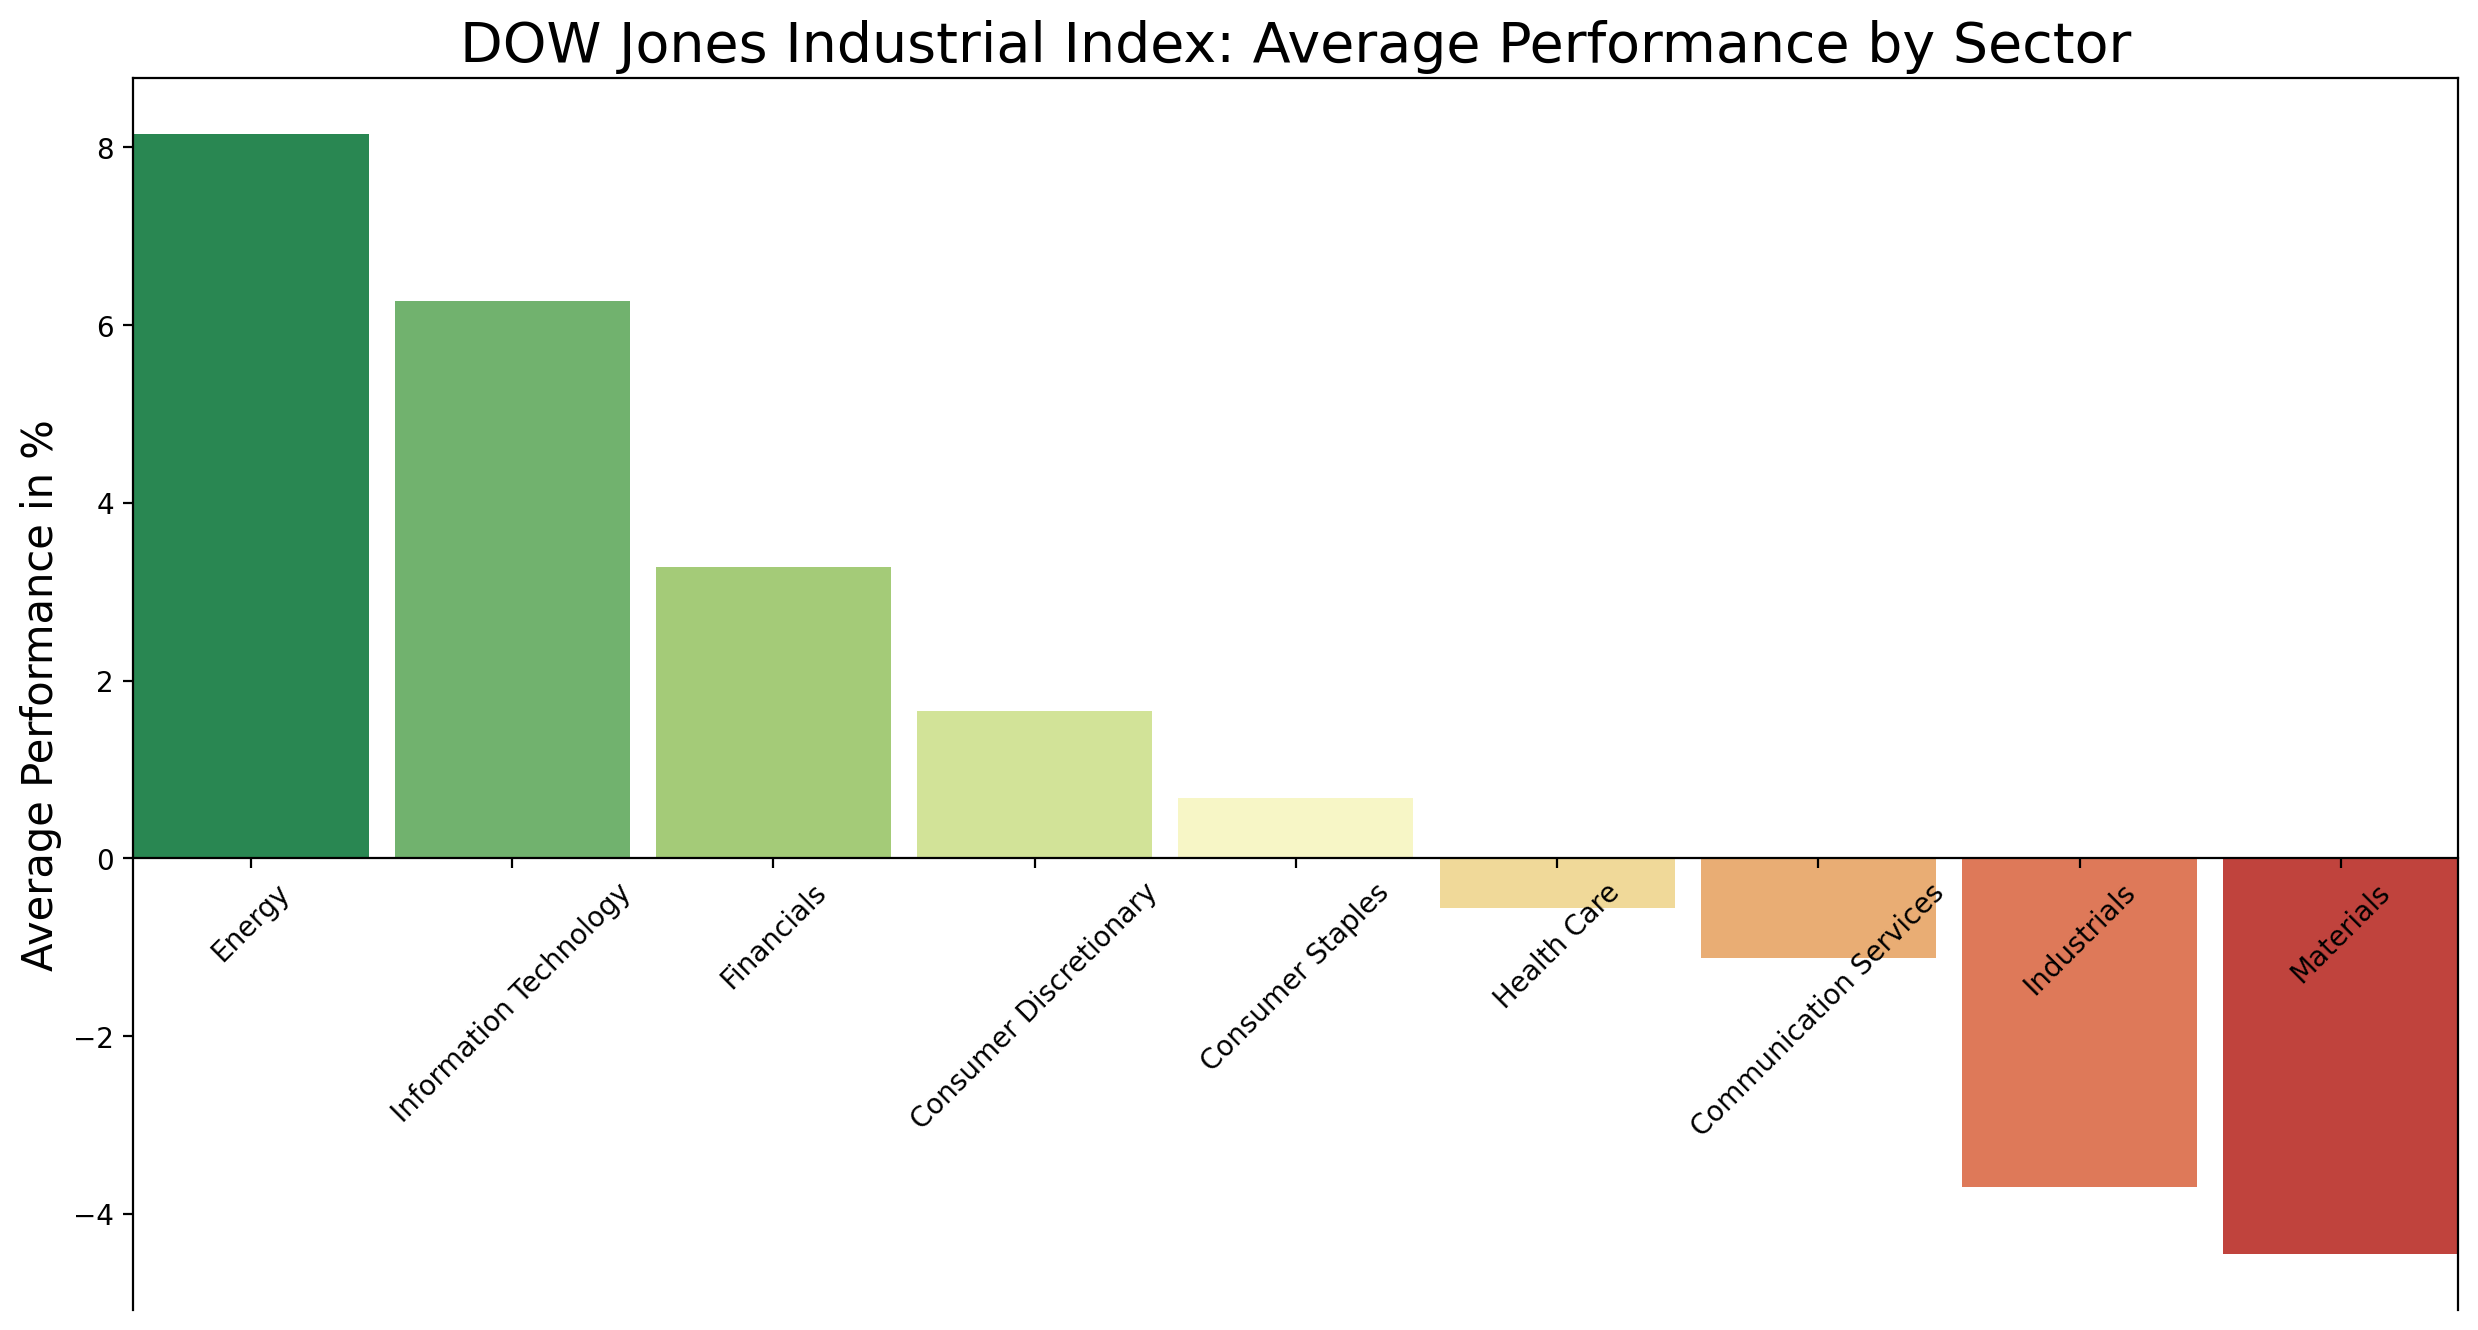

In [58]:
fig , ax = plt.subplots(figsize = (15, 8))
sns.barplot(data = sorted_df_DOW_JONES.groupby(["Sector"]).agg({"Performance": "mean"}).sort_values(by = "Performance", ascending = False), 
            x = "Sector", 
            y = "Performance", 
            hue = "Sector", 
            legend = False, 
            palette = "RdYlGn_r",
            errorbar = None , 
            width = .9)
ax.spines["bottom"].set_position(("data",0))
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.set_xlabel("", fontsize = 15)
ax.set_ylabel("Average Performance in %", fontsize = 15)
ax.set_title("DOW Jones Industrial Index: Average Performance by Sector", fontsize = 20)
ax.autoscale(enable = True, axis = "x", tight = True)
plt.show()

## More detailed Stock Data (cross-sectional)

__yfinance__ (recommended, much faster than yahooquery)

In [59]:
msft = yf.Ticker(ticker = "msft") 
msft

yfinance.Ticker object <MSFT>

In [60]:
msft.get_info()["sector"]

'Technology'

In [61]:
msft.get_info()["industry"]

'Software - Infrastructure'

In [62]:
msft.get_info()

{'address1': 'One Microsoft Way',
 'city': 'Redmond',
 'state': 'WA',
 'zip': '98052-6399',
 'country': 'United States',
 'phone': '425 882 8080',
 'website': 'https://www.microsoft.com',
 'industry': 'Software - Infrastructure',
 'industryKey': 'software-infrastructure',
 'industryDisp': 'Software - Infrastructure',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Microsoft Corporation develops and supports software, services, devices, and solutions worldwide. The Productivity and Business Processes segment offers Microsoft 365 commercial, enterprise mobility + security, windows commercial, power BI, exchange, sharepoint, Microsoft teams, security and compliance, and copilot; Microsoft 365 commercial products, such as Windows commercial on-premises and office licensed services; Microsoft 365 consumer products and cloud services, including Microsoft 365 consumer subscriptions, office licensed on-premises, and other consumer serv

In [63]:
info = pd.Series(msft.get_info()).to_frame().T
info

,address1,city,state,zip,country,phone,website,industry,industryKey,industryDisp,...,fiftyDayAverageChange,fiftyDayAverageChangePercent,twoHundredDayAverageChange,twoHundredDayAverageChangePercent,sourceInterval,exchangeDataDelayedBy,averageAnalystRating,cryptoTradeable,displayName,trailingPegRatio
0,One Microsoft Way,Redmond,WA,98052-6399,United States,425 882 8080,https://www.microsoft.com,Software - Infrastructure,software-infrastructure,Software - Infrastructure,...,-12.63,-0.03,-51.29,-0.12,15,0,1.3 - Strong Buy,False,Microsoft,1.19


In [ ]:
cs = pd.DataFrame() # cs stand for company summary
cs 

""


In [65]:
symbols

['MMM',
 'GOOGL',
 'AXP',
 'AMGN',
 'AMZN',
 'AAPL',
 'BA',
 'CAT',
 'CVX',
 'CSCO',
 'KO',
 'DIS',
 'GS',
 'HD',
 'HON',
 'IBM',
 'JNJ',
 'JPM',
 'MCD',
 'MRK',
 'MSFT',
 'NKE',
 'NVDA',
 'PG',
 'CRM',
 'SHW',
 'TRV',
 'UNH',
 'V',
 'WMT']

In [66]:
count = 0
for symbol in symbols:
    try:
        info = pd.Series(yf.Ticker(ticker = symbol).get_info()).to_frame().T
        cs = pd.concat([cs, info])
        print(count, end = '\r')
        count += 1
    except Exception as e:
        print("{} not found".format(symbol))
print(f"Download complete. {count} symbols downloaded.")


Download complete. 30 symbols downloaded.


In [67]:
cs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 0
Columns: 190 entries, address1 to industrySymbol
dtypes: object(190)
memory usage: 44.8+ KB


In [68]:
cs["symbol"] = symbols # Added

In [69]:
cs

,address1,city,state,zip,country,phone,website,industry,industryKey,industryDisp,...,shortName,longName,trailingPegRatio,fax,displayName,address2,ipoExpectedDate,prevName,nameChangeDate,industrySymbol
0,3M Center,Saint Paul,MN,55144-1000,United States,651 733 1110,https://www.3m.com,Conglomerates,conglomerates,Conglomerates,...,3M Company,3M Company,1.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1600 Amphitheatre Parkway,Mountain View,CA,94043,United States,650-253-0000,https://abc.xyz,Internet Content & Information,internet-content-information,Internet Content & Information,...,Alphabet Inc.,Alphabet Inc.,1.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,200 Vesey Street,New York,NY,10285,United States,(212) 640-2000,https://www.americanexpress.com,Credit Services,credit-services,Credit Services,...,American Express Company,American Express Company,1.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,One Amgen Center Drive,Thousand Oaks,CA,91320-1799,United States,805 447 1000,https://www.amgen.com,Drug Manufacturers - General,drug-manufacturers-general,Drug Manufacturers - General,...,Amgen Inc.,Amgen Inc.,1.99,805 447 1010,Amgen,NaN,NaN,NaN,NaN,NaN
0,410 Terry Avenue North,Seattle,WA,98109-5210,United States,206 266 1000,https://www.amazon.com,Internet Retail,internet-retail,Internet Retail,...,"Amazon.com, Inc.","Amazon.com, Inc.",1.41,NaN,Amazon.com,NaN,NaN,NaN,NaN,NaN
0,One Apple Park Way,Cupertino,CA,95014,United States,(408) 996-1010,https://www.apple.com,Consumer Electronics,consumer-electronics,Consumer Electronics,...,Apple Inc.,Apple Inc.,2.55,NaN,Apple,NaN,NaN,NaN,NaN,NaN
0,929 Long Bridge Drive,Arlington,VA,22202-4208,United States,703-465-3500,https://www.boeing.com,Aerospace & Defense,aerospace-defense,Aerospace & Defense,...,Boeing Company (The),The Boeing Company,24.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,5205 N. O'Connor Boulevard,Irving,TX,75039,United States,972 891 7700,https://www.caterpillar.com,Farm & Heavy Construction Machinery,farm-heavy-construction-machinery,Farm & Heavy Construction Machinery,...,"Caterpillar, Inc.",Caterpillar Inc.,2.24,309 494 4818,Caterpillar,Suite 100,NaN,NaN,NaN,NaN
0,1400 Smith Street,Houston,TX,77002-7327,United States,832 854 1000,https://www.chevron.com,Oil & Gas Integrated,oil-gas-integrated,Oil & Gas Integrated,...,Chevron Corporation,Chevron Corporation,0.73,NaN,Chevron,NaN,NaN,NaN,NaN,NaN
0,170 West Tasman Drive,San Jose,CA,95134-1706,United States,(408) 526-4000,https://www.cisco.com,Communication Equipment,communication-equipment,Communication Equipment,...,"Cisco Systems, Inc.","Cisco Systems, Inc.",1.68,NaN,Cisco Systems,NaN,NaN,NaN,NaN,NaN


In [70]:
cs.set_index("symbol", inplace = True)

In [71]:
cs.index.name = "Symbol"
cs

,address1,city,state,zip,country,phone,website,industry,industryKey,industryDisp,...,shortName,longName,trailingPegRatio,fax,displayName,address2,ipoExpectedDate,prevName,nameChangeDate,industrySymbol
Symbol,,,,,,,,,,,,,,,,,,,,,
MMM,3M Center,Saint Paul,MN,55144-1000,United States,651 733 1110,https://www.3m.com,Conglomerates,conglomerates,Conglomerates,...,3M Company,3M Company,1.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GOOGL,1600 Amphitheatre Parkway,Mountain View,CA,94043,United States,650-253-0000,https://abc.xyz,Internet Content & Information,internet-content-information,Internet Content & Information,...,Alphabet Inc.,Alphabet Inc.,1.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AXP,200 Vesey Street,New York,NY,10285,United States,(212) 640-2000,https://www.americanexpress.com,Credit Services,credit-services,Credit Services,...,American Express Company,American Express Company,1.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMGN,One Amgen Center Drive,Thousand Oaks,CA,91320-1799,United States,805 447 1000,https://www.amgen.com,Drug Manufacturers - General,drug-manufacturers-general,Drug Manufacturers - General,...,Amgen Inc.,Amgen Inc.,1.99,805 447 1010,Amgen,NaN,NaN,NaN,NaN,NaN
AMZN,410 Terry Avenue North,Seattle,WA,98109-5210,United States,206 266 1000,https://www.amazon.com,Internet Retail,internet-retail,Internet Retail,...,"Amazon.com, Inc.","Amazon.com, Inc.",1.41,NaN,Amazon.com,NaN,NaN,NaN,NaN,NaN
AAPL,One Apple Park Way,Cupertino,CA,95014,United States,(408) 996-1010,https://www.apple.com,Consumer Electronics,consumer-electronics,Consumer Electronics,...,Apple Inc.,Apple Inc.,2.55,NaN,Apple,NaN,NaN,NaN,NaN,NaN
BA,929 Long Bridge Drive,Arlington,VA,22202-4208,United States,703-465-3500,https://www.boeing.com,Aerospace & Defense,aerospace-defense,Aerospace & Defense,...,Boeing Company (The),The Boeing Company,24.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAT,5205 N. O'Connor Boulevard,Irving,TX,75039,United States,972 891 7700,https://www.caterpillar.com,Farm & Heavy Construction Machinery,farm-heavy-construction-machinery,Farm & Heavy Construction Machinery,...,"Caterpillar, Inc.",Caterpillar Inc.,2.24,309 494 4818,Caterpillar,Suite 100,NaN,NaN,NaN,NaN
CVX,1400 Smith Street,Houston,TX,77002-7327,United States,832 854 1000,https://www.chevron.com,Oil & Gas Integrated,oil-gas-integrated,Oil & Gas Integrated,...,Chevron Corporation,Chevron Corporation,0.73,NaN,Chevron,NaN,NaN,NaN,NaN,NaN


In [72]:
cs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, MMM to WMT
Columns: 189 entries, address1 to industrySymbol
dtypes: object(189)
memory usage: 44.5+ KB


__yahooquery__ (slow, better use yfinance)

In [73]:
%pip install yahooquery --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.1 MB/s eta 0:00:00a 0:00:01


In [74]:
import yahooquery as yq

In [75]:
msft = yq.Ticker("MSFT")
msft

In [76]:
msft.key_stats

{'MSFT': {'maxAge': 1,
  'priceHint': 2,
  'enterpriseValue': 2951647592448,
  'forwardPE': 20.195818,
  'profitMargins': 0.39341998,
  'floatShares': 7417366336,
  'sharesOutstanding': 7428434704,
  'sharesShort': 89063316,
  'sharesShortPriorMonth': 88696120,
  'sharesShortPreviousMonthDate': '2026-05-29 00:00:00',
  'dateShortInterest': '2026-06-30 00:00:00',
  'sharesPercentSharesOut': 0.012,
  'heldPercentInsiders': 0.00078,
  'heldPercentInstitutions': 0.75663,
  'shortRatio': 1.84,
  'shortPercentOfFloat': 0.012,
  'beta': 1.13,
  'impliedSharesOutstanding': 7428434704,
  'category': None,
  'bookValue': 55.777,
  'priceToBook': 7.009878,
  'fundFamily': None,
  'legalType': None,
  'lastFiscalYearEnd': '2025-06-30 00:00:00',
  'nextFiscalYearEnd': '2026-06-30 00:00:00',
  'mostRecentQuarter': '2026-03-31 00:00:00',
  'earningsQuarterlyGrowth': 0.231,
  'netIncomeToCommon': 125215997952,
  'trailingEps': 16.79,
  'forwardEps': 19.35995,
  'pegRatio': 1.19,
  'lastSplitFactor': '

In [77]:
msft.key_stats["MSFT"] # key statistics

{'maxAge': 1,
 'priceHint': 2,
 'enterpriseValue': 2951647592448,
 'forwardPE': 20.195818,
 'profitMargins': 0.39341998,
 'floatShares': 7417366336,
 'sharesOutstanding': 7428434704,
 'sharesShort': 89063316,
 'sharesShortPriorMonth': 88696120,
 'sharesShortPreviousMonthDate': '2026-05-29 00:00:00',
 'dateShortInterest': '2026-06-30 00:00:00',
 'sharesPercentSharesOut': 0.012,
 'heldPercentInsiders': 0.00078,
 'heldPercentInstitutions': 0.75663,
 'shortRatio': 1.84,
 'shortPercentOfFloat': 0.012,
 'beta': 1.13,
 'impliedSharesOutstanding': 7428434704,
 'category': None,
 'bookValue': 55.777,
 'priceToBook': 7.009878,
 'fundFamily': None,
 'legalType': None,
 'lastFiscalYearEnd': '2025-06-30 00:00:00',
 'nextFiscalYearEnd': '2026-06-30 00:00:00',
 'mostRecentQuarter': '2026-03-31 00:00:00',
 'earningsQuarterlyGrowth': 0.231,
 'netIncomeToCommon': 125215997952,
 'trailingEps': 16.79,
 'forwardEps': 19.35995,
 'pegRatio': 1.19,
 'lastSplitFactor': '2:1',
 'lastSplitDate': '2003-02-18 00:0

In [78]:
msft.financial_data

{'MSFT': {'maxAge': 86400,
  'currentPrice': 390.99,
  'targetHighPrice': 870.0,
  'targetLowPrice': 400.0,
  'targetMeanPrice': 559.86035,
  'targetMedianPrice': 550.0,
  'recommendationMean': 1.32143,
  'recommendationKey': 'strong_buy',
  'numberOfAnalystOpinions': 55,
  'totalCash': 78227996672,
  'totalCashPerShare': 10.531,
  'ebitda': 184457003008,
  'totalDebt': 125431996416,
  'quickRatio': 1.142,
  'currentRatio': 1.283,
  'totalRevenue': 318272995328,
  'debtToEquity': 30.271,
  'revenuePerShare': 42.836,
  'returnOnAssets': 0.14814,
  'returnOnEquity': 0.34013999,
  'grossProfits': 217409994752,
  'freeCashflow': 37011251200,
  'operatingCashflow': 170141007872,
  'earningsGrowth': 0.234,
  'revenueGrowth': 0.183,
  'grossMargins': 0.68309,
  'ebitdaMargins': 0.57956004,
  'operatingMargins': 0.46326,
  'profitMargins': 0.39341998,
  'financialCurrency': 'USD'}}

In [79]:
msft.financial_data["MSFT"] # financial data

{'maxAge': 86400,
 'currentPrice': 390.99,
 'targetHighPrice': 870.0,
 'targetLowPrice': 400.0,
 'targetMeanPrice': 559.86035,
 'targetMedianPrice': 550.0,
 'recommendationMean': 1.32143,
 'recommendationKey': 'strong_buy',
 'numberOfAnalystOpinions': 55,
 'totalCash': 78227996672,
 'totalCashPerShare': 10.531,
 'ebitda': 184457003008,
 'totalDebt': 125431996416,
 'quickRatio': 1.142,
 'currentRatio': 1.283,
 'totalRevenue': 318272995328,
 'debtToEquity': 30.271,
 'revenuePerShare': 42.836,
 'returnOnAssets': 0.14814,
 'returnOnEquity': 0.34013999,
 'grossProfits': 217409994752,
 'freeCashflow': 37011251200,
 'operatingCashflow': 170141007872,
 'earningsGrowth': 0.234,
 'revenueGrowth': 0.183,
 'grossMargins': 0.68309,
 'ebitdaMargins': 0.57956004,
 'operatingMargins': 0.46326,
 'profitMargins': 0.39341998,
 'financialCurrency': 'USD'}

In [80]:
msft.summary_detail["MSFT"] # summary statistics

{'maxAge': 1,
 'priceHint': 2,
 'previousClose': 385.1,
 'open': 387.725,
 'dayLow': 384.15,
 'dayHigh': 393.64,
 'regularMarketPreviousClose': 385.1,
 'regularMarketOpen': 387.725,
 'regularMarketDayLow': 384.15,
 'regularMarketDayHigh': 393.64,
 'dividendRate': 3.64,
 'dividendYield': 0.0095,
 'exDividendDate': '2026-08-20 00:00:00',
 'payoutRatio': 0.20729999,
 'fiveYearAvgDividendYield': 0.79,
 'beta': 1.13,
 'trailingPE': 23.287073,
 'forwardPE': 20.195818,
 'volume': 27505099,
 'regularMarketVolume': 27505099,
 'averageVolume': 40166318,
 'averageVolume10days': 51769760,
 'averageDailyVolume10Day': 51769760,
 'bid': 389.21,
 'ask': 400.0,
 'bidSize': 100,
 'askSize': 100,
 'marketCap': 2904443584512,
 'nonDilutedMarketCap': 2860690204510,
 'fiftyTwoWeekLow': 349.2,
 'fiftyTwoWeekHigh': 555.45,
 'allTimeHigh': 555.45,
 'allTimeLow': 0.088542,
 'priceToSalesTrailing12Months': 9.125636,
 'fiftyDayAverage': 403.6158,
 'twoHundredDayAverage': 442.27856,
 'trailingAnnualDividendRate': 

In [81]:
symbols

['MMM',
 'GOOGL',
 'AXP',
 'AMGN',
 'AMZN',
 'AAPL',
 'BA',
 'CAT',
 'CVX',
 'CSCO',
 'KO',
 'DIS',
 'GS',
 'HD',
 'HON',
 'IBM',
 'JNJ',
 'JPM',
 'MCD',
 'MRK',
 'MSFT',
 'NKE',
 'NVDA',
 'PG',
 'CRM',
 'SHW',
 'TRV',
 'UNH',
 'V',
 'WMT']

In [82]:
aapl_info = yq.Ticker("AAPL").key_stats["AAPL"]

In [83]:
aapl_info.update(yq.Ticker("AAPL").financial_data["AAPL"])

In [84]:
aapl_info

{'maxAge': 86400,
 'priceHint': 2,
 'enterpriseValue': 4647420952576,
 'forwardPE': 33.02234,
 'profitMargins': 0.27152002,
 'floatShares': 14662387495,
 'sharesOutstanding': 14687356000,
 'sharesShort': 140526320,
 'sharesShortPriorMonth': 155886024,
 'sharesShortPreviousMonthDate': '2026-05-29 00:00:00',
 'dateShortInterest': '2026-06-30 00:00:00',
 'sharesPercentSharesOut': 0.0095999995,
 'heldPercentInsiders': 0.01631,
 'heldPercentInstitutions': 0.65732,
 'shortRatio': 2.11,
 'shortPercentOfFloat': 0.0095999995,
 'beta': 1.097,
 'impliedSharesOutstanding': 14687356000,
 'category': None,
 'bookValue': 7.26,
 'priceToBook': 43.70661,
 'fundFamily': None,
 'legalType': None,
 'lastFiscalYearEnd': '2025-09-27 00:00:00',
 'nextFiscalYearEnd': '2026-09-27 00:00:00',
 'mostRecentQuarter': '2026-03-28 00:00:00',
 'earningsQuarterlyGrowth': 0.194,
 'netIncomeToCommon': 122575003648,
 'trailingEps': 8.26,
 'forwardEps': 9.61274,
 'pegRatio': 2.55,
 'lastSplitFactor': '4:1',
 'lastSplitDate

In [ ]:
#cross sectional data with yahooquery
cs_yq = pd.DataFrame()
cs_yq

""


In [86]:
count = 0
for symbol in symbols:
    try:
        all_info = yq.Ticker(symbol).key_stats[symbol] # key statistics
        all_info.update(yq.Ticker(symbol).financial_data[symbol]) # financial data
        all_info.update(yq.Ticker(symbol).summary_detail[symbol]) # summary_details
        all_info = pd.Series(all_info).to_frame().T
        cs_yq = pd.concat([cs_yq, all_info])
        print(count, end = '\r')
        count += 1
    except Exception as e:
        print("{} not found".format(symbol))
print("Download completed. {} symbols downloaded.".format(count))


Download completed. 30 symbols downloaded.


In [87]:
cs_yq["symbol"] = symbols # Added

In [88]:
cs_yq

,maxAge,priceHint,enterpriseValue,forwardPE,profitMargins,floatShares,sharesOutstanding,sharesShort,sharesShortPriorMonth,sharesShortPreviousMonthDate,...,trailingAnnualDividendRate,trailingAnnualDividendYield,currency,fromCurrency,toCurrency,lastMarket,coinMarketCapLink,algorithm,tradeable,symbol
0,1,2,89608159232,16.61,0.11,520670165,521567261,9794330,9588196,2026-05-29 00:00:00,...,2.97,0.02,USD,None,None,None,None,None,False,MMM
0,1,2,4296628764672,24.09,0.38,10821405400,5867155790,85860436,82913646,2026-05-29 00:00:00,...,0.84,0.00,USD,None,None,None,None,None,False,GOOGL
0,1,2,245802008576,17.57,0.16,529246506,682326443,10839567,12044280,2026-05-29 00:00:00,...,3.41,0.01,USD,None,None,None,None,None,False,AXP
0,1,2,241409589248,15.39,0.21,538224076,539708274,12870865,11852360,2026-05-29 00:00:00,...,9.66,0.03,USD,None,None,None,None,None,False,AMGN
0,1,2,2731600248832,25.02,0.12,9779826044,10757109436,100349673,92450944,2026-05-29 00:00:00,...,0.00,0.00,USD,None,None,None,None,None,False,AMZN
0,1,2,4647420952576,33.01,0.27,14662387495,14687356000,140526320,155886024,2026-05-29 00:00:00,...,1.04,0.00,USD,None,None,None,None,None,False,AAPL
0,1,2,199329038336,52.70,0.02,756415502,788302331,149665,543354,2026-05-29 00:00:00,...,0.00,0.00,USD,None,None,None,None,None,False,BA
0,1,2,468818558976,30.65,0.13,459181413,460591983,9052419,8103454,2026-05-29 00:00:00,...,6.04,0.01,USD,None,None,None,None,None,False,CAT
0,1,2,406044704768,14.53,0.06,1882374685,1991597732,18851523,22909437,2026-05-29 00:00:00,...,6.91,0.04,USD,None,None,None,None,None,False,CVX
0,1,2,494496448512,24.96,0.20,3935128370,3941434665,53800162,61949954,2026-05-29 00:00:00,...,1.65,0.01,USD,None,None,None,None,None,False,CSCO


In [89]:
cs_yq.set_index("symbol", inplace = True)

In [90]:
cs_yq

,maxAge,priceHint,enterpriseValue,forwardPE,profitMargins,floatShares,sharesOutstanding,sharesShort,sharesShortPriorMonth,sharesShortPreviousMonthDate,...,twoHundredDayAverage,trailingAnnualDividendRate,trailingAnnualDividendYield,currency,fromCurrency,toCurrency,lastMarket,coinMarketCapLink,algorithm,tradeable
symbol,,,,,,,,,,,,,,,,,,,,,
MMM,1,2,89608159232,16.61,0.11,520670165,521567261,9794330,9588196,2026-05-29 00:00:00,...,158.04,2.97,0.02,USD,None,None,None,None,None,False
GOOGL,1,2,4296628764672,24.09,0.38,10821405400,5867155790,85860436,82913646,2026-05-29 00:00:00,...,318.91,0.84,0.00,USD,None,None,None,None,None,False
AXP,1,2,245802008576,17.57,0.16,529246506,682326443,10839567,12044280,2026-05-29 00:00:00,...,338.42,3.41,0.01,USD,None,None,None,None,None,False
AMGN,1,2,241409589248,15.39,0.21,538224076,539708274,12870865,11852360,2026-05-29 00:00:00,...,337.51,9.66,0.03,USD,None,None,None,None,None,False
AMZN,1,2,2731600248832,25.02,0.12,9779826044,10757109436,100349673,92450944,2026-05-29 00:00:00,...,233.33,0.00,0.00,USD,None,None,None,None,None,False
AAPL,1,2,4647420952576,33.01,0.27,14662387495,14687356000,140526320,155886024,2026-05-29 00:00:00,...,272.45,1.04,0.00,USD,None,None,None,None,None,False
BA,1,2,199329038336,52.70,0.02,756415502,788302331,149665,543354,2026-05-29 00:00:00,...,218.64,0.00,0.00,USD,None,None,None,None,None,False
CAT,1,2,468818558976,30.65,0.13,459181413,460591983,9052419,8103454,2026-05-29 00:00:00,...,709.04,6.04,0.01,USD,None,None,None,None,None,False
CVX,1,2,406044704768,14.53,0.06,1882374685,1991597732,18851523,22909437,2026-05-29 00:00:00,...,172.81,6.91,0.04,USD,None,None,None,None,None,False


In [91]:
cs_yq.index.name = "Symbol"
cs_yq

,maxAge,priceHint,enterpriseValue,forwardPE,profitMargins,floatShares,sharesOutstanding,sharesShort,sharesShortPriorMonth,sharesShortPreviousMonthDate,...,twoHundredDayAverage,trailingAnnualDividendRate,trailingAnnualDividendYield,currency,fromCurrency,toCurrency,lastMarket,coinMarketCapLink,algorithm,tradeable
Symbol,,,,,,,,,,,,,,,,,,,,,
MMM,1,2,89608159232,16.61,0.11,520670165,521567261,9794330,9588196,2026-05-29 00:00:00,...,158.04,2.97,0.02,USD,None,None,None,None,None,False
GOOGL,1,2,4296628764672,24.09,0.38,10821405400,5867155790,85860436,82913646,2026-05-29 00:00:00,...,318.91,0.84,0.00,USD,None,None,None,None,None,False
AXP,1,2,245802008576,17.57,0.16,529246506,682326443,10839567,12044280,2026-05-29 00:00:00,...,338.42,3.41,0.01,USD,None,None,None,None,None,False
AMGN,1,2,241409589248,15.39,0.21,538224076,539708274,12870865,11852360,2026-05-29 00:00:00,...,337.51,9.66,0.03,USD,None,None,None,None,None,False
AMZN,1,2,2731600248832,25.02,0.12,9779826044,10757109436,100349673,92450944,2026-05-29 00:00:00,...,233.33,0.00,0.00,USD,None,None,None,None,None,False
AAPL,1,2,4647420952576,33.01,0.27,14662387495,14687356000,140526320,155886024,2026-05-29 00:00:00,...,272.45,1.04,0.00,USD,None,None,None,None,None,False
BA,1,2,199329038336,52.70,0.02,756415502,788302331,149665,543354,2026-05-29 00:00:00,...,218.64,0.00,0.00,USD,None,None,None,None,None,False
CAT,1,2,468818558976,30.65,0.13,459181413,460591983,9052419,8103454,2026-05-29 00:00:00,...,709.04,6.04,0.01,USD,None,None,None,None,None,False
CVX,1,2,406044704768,14.53,0.06,1882374685,1991597732,18851523,22909437,2026-05-29 00:00:00,...,172.81,6.91,0.04,USD,None,None,None,None,None,False


In [98]:
cs_yq.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, MMM to WMT
Columns: 110 entries, maxAge to tradeable
dtypes: object(110)
memory usage: 27.1+ KB


## Equity Analysis & Comparison

In [93]:
sorted_df_DOW_JONES

,Company,Exchange,Sector,Date_Added,Weights,Performance
Symbol,,,,,,
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.21,12.63
CRM,Salesforce,NYSE,Information Technology,2020-08-31,1.80,8.42
CVX,Chevron,NYSE,Energy,2008-02-19,1.92,8.15
MSFT,Microsoft,NASDAQ,Information Technology,1999-11-01,4.20,6.08
NKE,Nike,NYSE,Consumer Discretionary,2013-09-23,0.47,5.50
V,Visa,NYSE,Financials,2013-09-23,3.89,4.71
IBM,IBM,NYSE,Information Technology,1979-06-29,3.17,4.40
NVDA,Nvidia,NASDAQ,Information Technology,2024-11-08,2.22,4.39
AXP,American Express,NYSE,Financials,1982-08-30,3.88,4.26


In [119]:
cs_yq.iloc[: , :-7].info(max_cols = 110)

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, MMM to WMT
Data columns (total 103 columns):
 #    Column                        Non-Null Count  Dtype 
---   ------                        --------------  ----- 
 0    maxAge                        30 non-null     object
 1    priceHint                     30 non-null     object
 2    enterpriseValue               30 non-null     object
 3    forwardPE                     30 non-null     object
 4    profitMargins                 30 non-null     object
 5    floatShares                   30 non-null     object
 6    sharesOutstanding             30 non-null     object
 7    sharesShort                   30 non-null     object
 8    sharesShortPriorMonth         30 non-null     object
 9    sharesShortPreviousMonthDate  30 non-null     object
 10   dateShortInterest             30 non-null     object
 11   sharesPercentSharesOut        30 non-null     object
 12   heldPercentInsiders           30 non-null     object
 13   heldPer

In [132]:
pd.set_option('display.max_info_columns', 200)

In [134]:
print(cs_yq.iloc[: , :-7].info(max_cols = 103))

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, MMM to WMT
Data columns (total 103 columns):
 #    Column                        Non-Null Count  Dtype 
---   ------                        --------------  ----- 
 0    maxAge                        30 non-null     object
 1    priceHint                     30 non-null     object
 2    enterpriseValue               30 non-null     object
 3    forwardPE                     30 non-null     object
 4    profitMargins                 30 non-null     object
 5    floatShares                   30 non-null     object
 6    sharesOutstanding             30 non-null     object
 7    sharesShort                   30 non-null     object
 8    sharesShortPriorMonth         30 non-null     object
 9    sharesShortPreviousMonthDate  30 non-null     object
 10   dateShortInterest             30 non-null     object
 11   sharesPercentSharesOut        30 non-null     object
 12   heldPercentInsiders           30 non-null     object
 13   heldPer

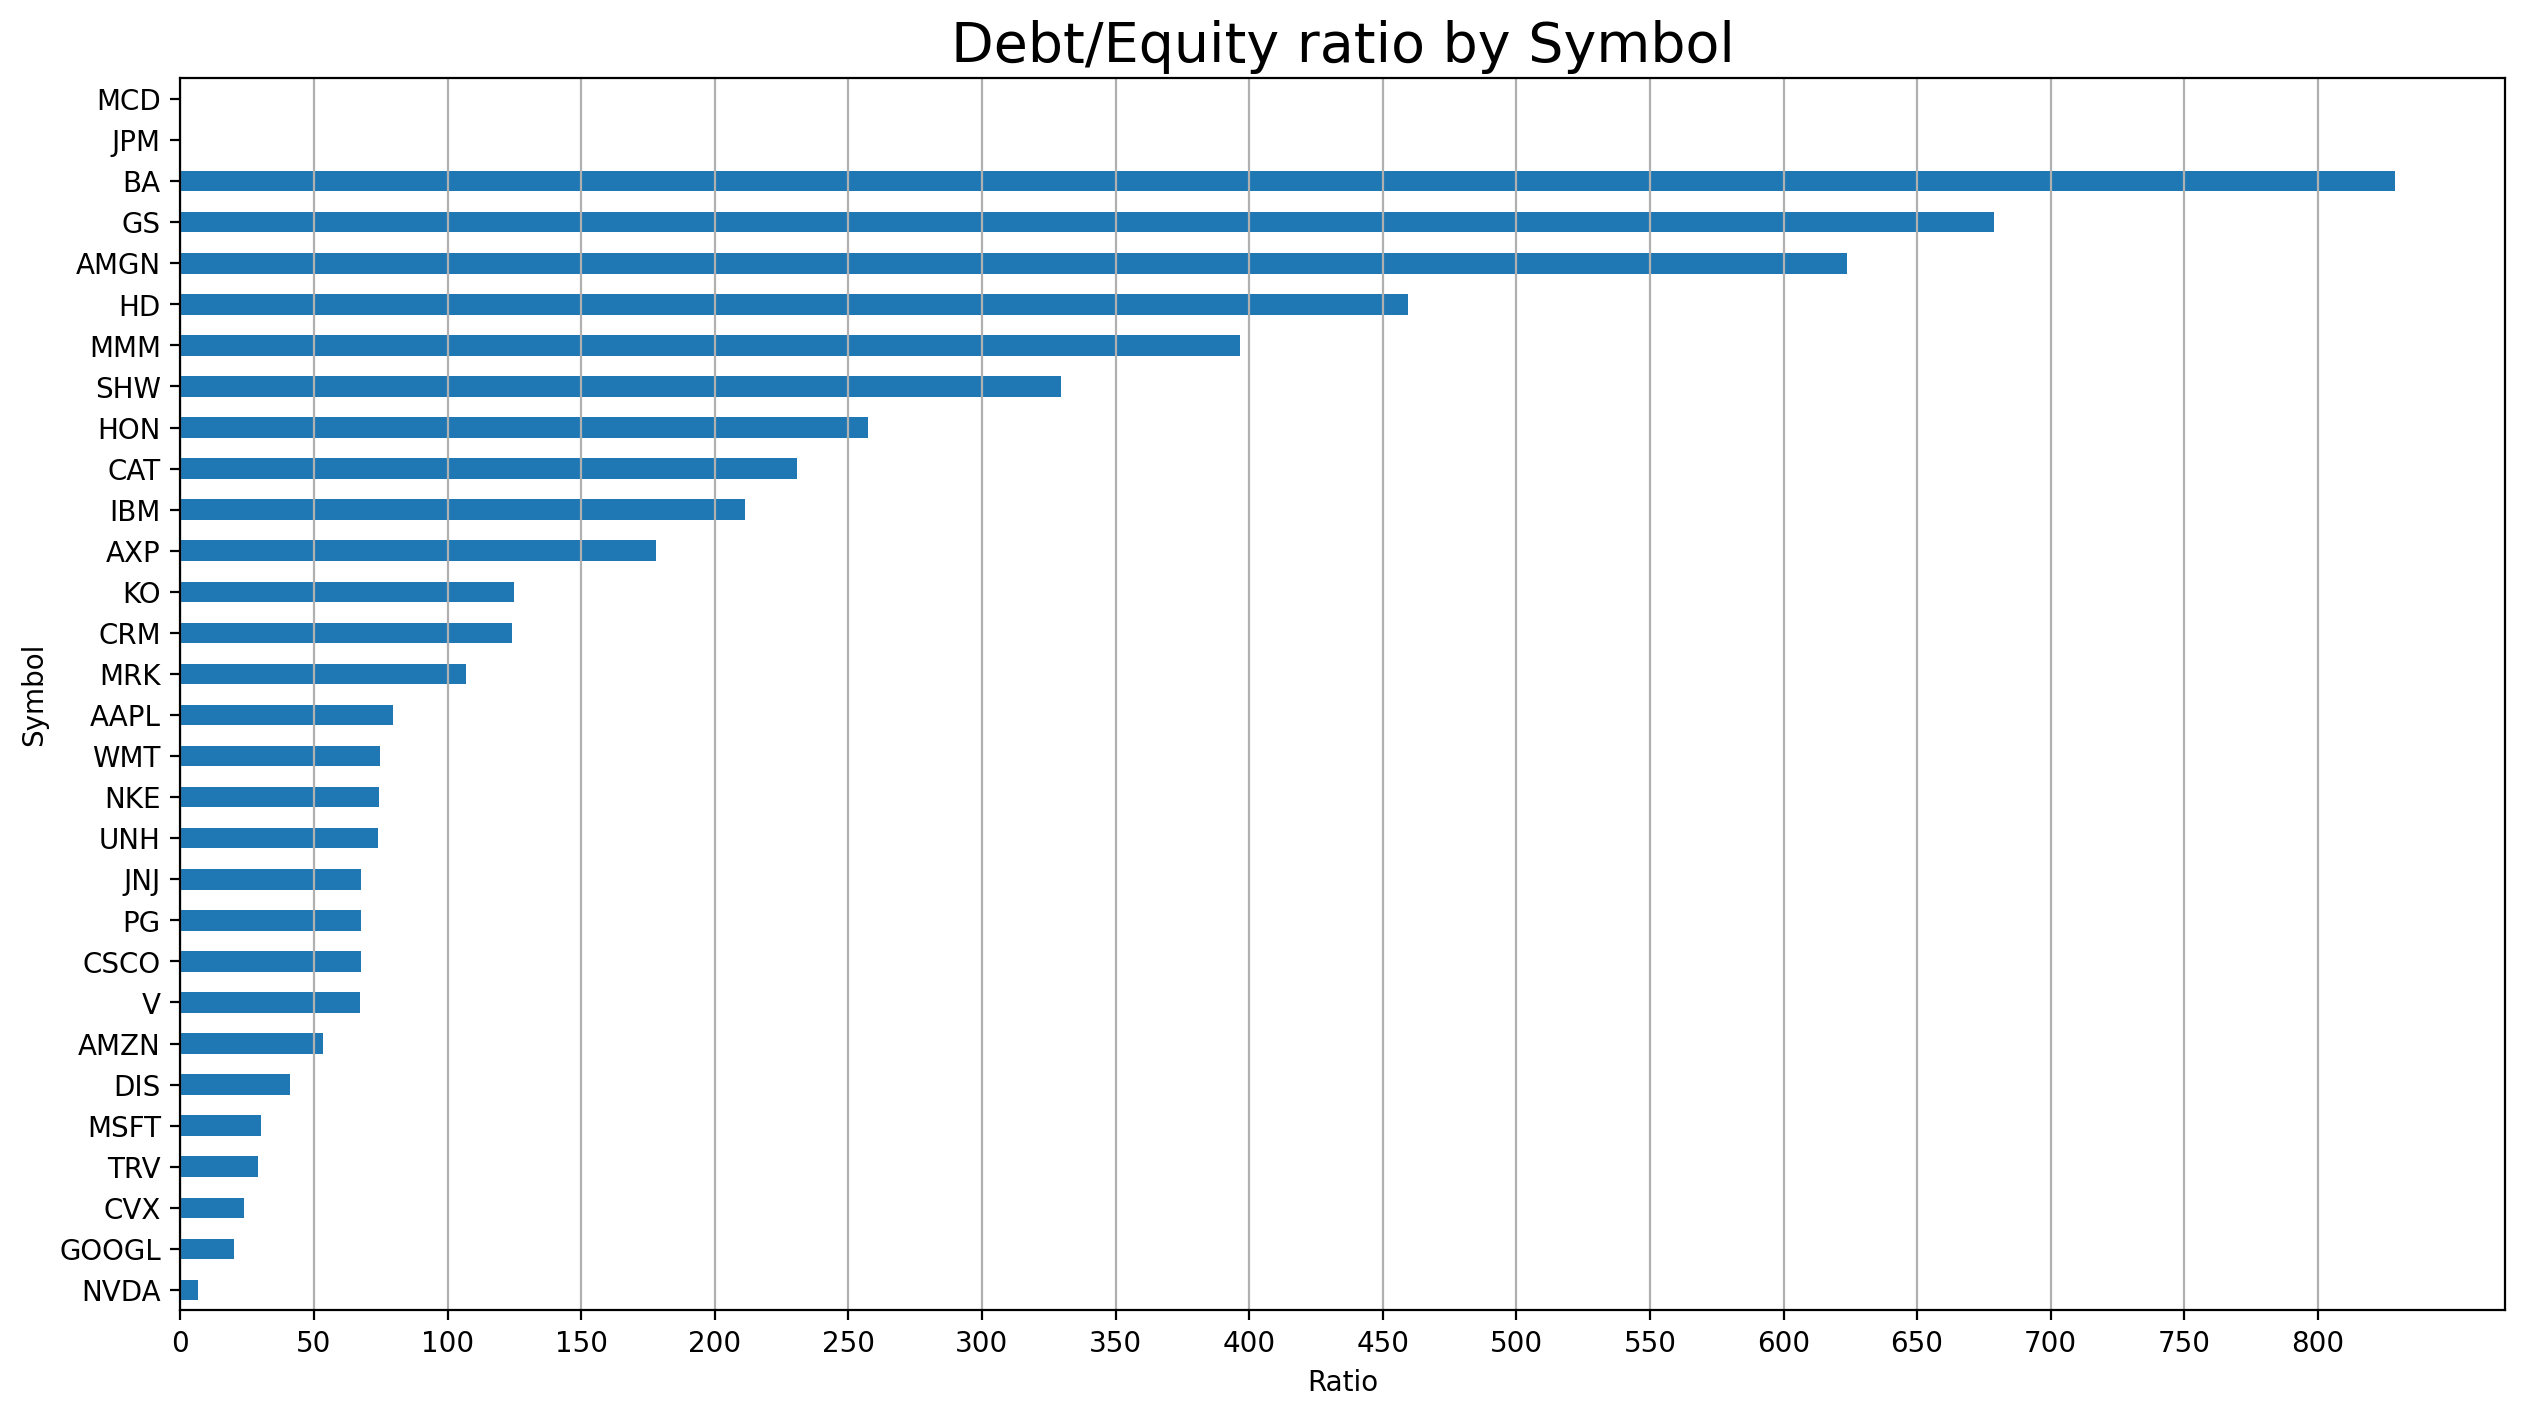

In [102]:
cs_yq["debtToEquity"].sort_values(ascending = True).plot.barh(figsize = (15, 8))
plt.xticks(range(0,800+50,50))
plt.grid(axis = "x")
plt.ylabel("Symbol")
plt.xlabel("Ratio")
plt.title("Debt/Equity ratio by Symbol", fontsize = 20)
plt.show()

__Price-to-Book ratio__ 

In [103]:
cs_yq["priceToBook"].sort_values(ascending = False)

,priceToBook
Symbol,
AAPL,43.71
BA,28.39
NVDA,25.22
MMM,25.21
HD,24.22
CAT,22.99
AMGN,21.17
V,19.19
SHW,18.20


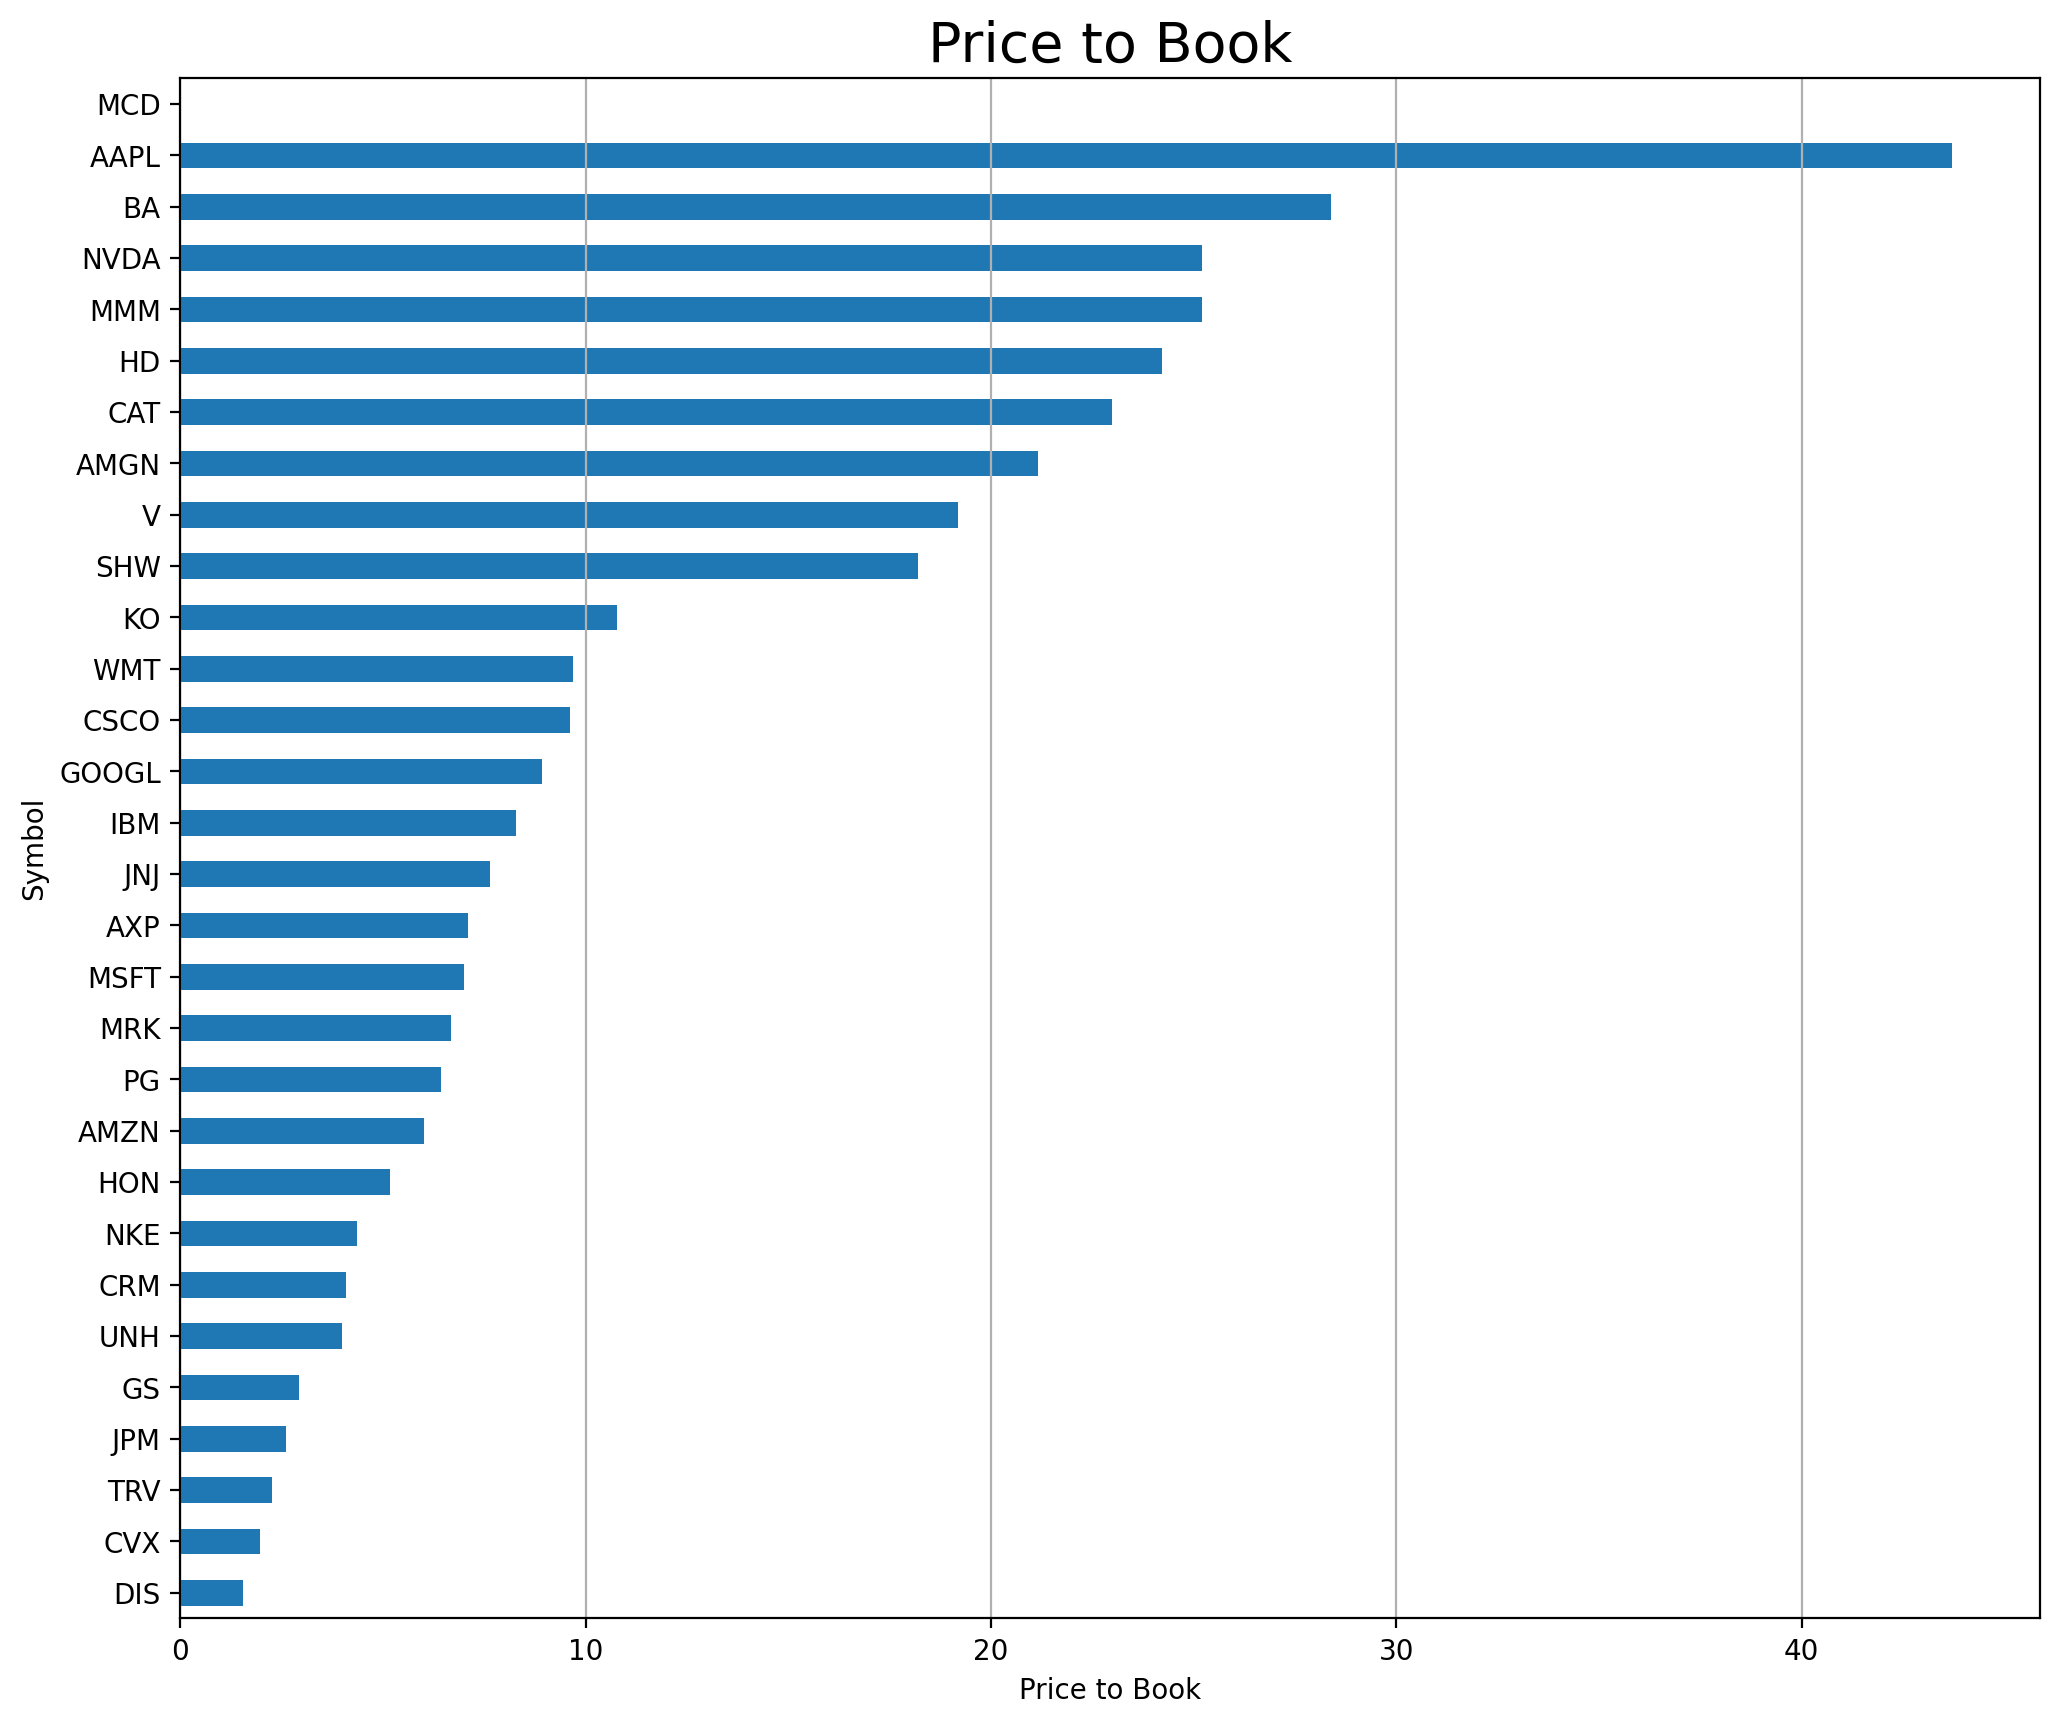

In [104]:
cs_yq["priceToBook"].sort_values(ascending = True).plot(kind = "barh" , figsize = (12, 10))
plt.grid(axis = "x")
plt.ylabel("Symbol")
plt.xlabel("Price to Book")
plt.title("Price to Book", fontsize = 20)
plt.show()

In [135]:
cs_yq.loc["BA", "bookValue"]

7.591

__-> negative/close to zero Book Value of Equity distorts P/B ratio__

In [136]:
sorted_df_DOW_JONES["PricetoBook"] = (cs_yq.currentPrice / cs_yq.bookValue)
sorted_df_DOW_JONES

,Company,Exchange,Sector,Date_Added,Weights,Performance,PricetoBook
Symbol,,,,,,,
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.21,12.63,43.71
CRM,Salesforce,NYSE,Information Technology,2020-08-31,1.80,8.42,4.10
CVX,Chevron,NYSE,Energy,2008-02-19,1.92,8.15,1.96
MSFT,Microsoft,NASDAQ,Information Technology,1999-11-01,4.20,6.08,7.01
NKE,Nike,NYSE,Consumer Discretionary,2013-09-23,0.47,5.50,4.36
V,Visa,NYSE,Financials,2013-09-23,3.89,4.71,19.19
IBM,IBM,NYSE,Information Technology,1979-06-29,3.17,4.40,8.27
NVDA,Nvidia,NASDAQ,Information Technology,2024-11-08,2.22,4.39,25.22
AXP,American Express,NYSE,Financials,1982-08-30,3.88,4.26,7.11


__Dividend Yield__ (Dividend per Share / Price)

In [138]:
cs_yq.dividendYield

,dividendYield
Symbol,
MMM,0.02
GOOGL,0.00
AXP,0.01
AMGN,0.03
AMZN,NaN
AAPL,0.00
BA,NaN
CAT,0.01
CVX,0.04


In [139]:
sorted_df_DOW_JONES["Dividend_Yield"] = cs_yq.dividendYield.fillna(0)
sorted_df_DOW_JONES

/tmp/ipykernel_913/3952592604.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sorted_df_DOW_JONES["Dividend_Yield"] = cs_yq.dividendYield.fillna(0)


,Company,Exchange,Sector,Date_Added,Weights,Performance,PricetoBook,Dividend_Yield
Symbol,,,,,,,,
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.21,12.63,43.71,0.00
CRM,Salesforce,NYSE,Information Technology,2020-08-31,1.80,8.42,4.10,0.01
CVX,Chevron,NYSE,Energy,2008-02-19,1.92,8.15,1.96,0.04
MSFT,Microsoft,NASDAQ,Information Technology,1999-11-01,4.20,6.08,7.01,0.01
NKE,Nike,NYSE,Consumer Discretionary,2013-09-23,0.47,5.50,4.36,0.04
V,Visa,NYSE,Financials,2013-09-23,3.89,4.71,19.19,0.01
IBM,IBM,NYSE,Information Technology,1979-06-29,3.17,4.40,8.27,0.02
NVDA,Nvidia,NASDAQ,Information Technology,2024-11-08,2.22,4.39,25.22,0.00
AXP,American Express,NYSE,Financials,1982-08-30,3.88,4.26,7.11,0.01


__Forward Price-to-Earnings Ratio__

In [140]:
sorted_df_DOW_JONES["ForwardPE"] = cs_yq.forwardPE
sorted_df_DOW_JONES

,Company,Exchange,Sector,Date_Added,Weights,Performance,PricetoBook,Dividend_Yield,ForwardPE
Symbol,,,,,,,,,
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.21,12.63,43.71,0.00,33.01
CRM,Salesforce,NYSE,Information Technology,2020-08-31,1.80,8.42,4.10,0.01,11.04
CVX,Chevron,NYSE,Energy,2008-02-19,1.92,8.15,1.96,0.04,14.53
MSFT,Microsoft,NASDAQ,Information Technology,1999-11-01,4.20,6.08,7.01,0.01,20.20
NKE,Nike,NYSE,Consumer Discretionary,2013-09-23,0.47,5.50,4.36,0.04,18.51
V,Visa,NYSE,Financials,2013-09-23,3.89,4.71,19.19,0.01,24.06
IBM,IBM,NYSE,Information Technology,1979-06-29,3.17,4.40,8.27,0.02,21.55
NVDA,Nvidia,NASDAQ,Information Technology,2024-11-08,2.22,4.39,25.22,0.00,15.91
AXP,American Express,NYSE,Financials,1982-08-30,3.88,4.26,7.11,0.01,17.57


__Comparison__

In [141]:
sorted_df_DOW_JONES.sort_values("PricetoBook", ascending = False)

,Company,Exchange,Sector,Date_Added,Weights,Performance,PricetoBook,Dividend_Yield,ForwardPE
Symbol,,,,,,,,,
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.21,12.63,43.71,0.00,33.01
BA,Boeing,NYSE,Industrials,1987-03-12,2.45,0.38,28.39,0.00,52.70
NVDA,Nvidia,NASDAQ,Information Technology,2024-11-08,2.22,4.39,25.22,0.00,15.91
MMM,3M,NYSE,Industrials,1976-08-09,1.85,-2.91,25.21,0.02,16.61
HD,Home Depot,NYSE,Consumer Discretionary,1999-11-01,4.00,-3.91,24.22,0.03,20.95
CAT,Caterpillar,NYSE,Industrials,1991-05-06,11.77,-9.85,22.99,0.01,30.65
AMGN,Amgen,NASDAQ,Health Care,2020-08-31,4.11,-0.03,21.17,0.03,15.39
V,Visa,NYSE,Financials,2013-09-23,3.89,4.71,19.19,0.01,24.06
SHW,Sherwin-Williams,NYSE,Materials,2024-11-08,3.92,-4.45,18.20,0.01,24.80


In [142]:
sorted_df_DOW_JONES.sort_values("ForwardPE", ascending = False)

,Company,Exchange,Sector,Date_Added,Weights,Performance,PricetoBook,Dividend_Yield,ForwardPE
Symbol,,,,,,,,,
BA,Boeing,NYSE,Industrials,1987-03-12,2.45,0.38,28.39,0.00,52.70
WMT,Walmart,NASDAQ,Consumer Staples,1997-03-17,1.31,0.16,9.69,0.01,34.93
AAPL,Apple,NASDAQ,Information Technology,2015-03-19,3.21,12.63,43.71,0.00,33.01
CAT,Caterpillar,NYSE,Industrials,1991-05-06,11.77,-9.85,22.99,0.01,30.65
AMZN,Amazon,NASDAQ,Consumer Discretionary,2024-02-26,2.74,2.99,6.02,0.00,25.02
CSCO,Cisco,NASDAQ,Information Technology,2009-06-08,1.34,1.70,9.62,0.01,24.96
SHW,Sherwin-Williams,NYSE,Materials,2024-11-08,3.92,-4.45,18.20,0.01,24.80
KO,Coca-Cola,NYSE,Consumer Staples,1987-03-12,0.94,1.94,10.78,0.03,24.21
GOOGL,Alphabet,NASDAQ,Communication Services,2026-06-29,4.03,-0.32,8.92,0.00,24.09


In [143]:
sorted_df_DOW_JONES.sort_values("Dividend_Yield", ascending = False)

,Company,Exchange,Sector,Date_Added,Weights,Performance,PricetoBook,Dividend_Yield,ForwardPE
Symbol,,,,,,,,,
HON,Honeywell Technologies,NASDAQ,Industrials,2020-08-31,2.59,-2.44,5.18,0.04,22.63
CVX,Chevron,NYSE,Energy,2008-02-19,1.92,8.15,1.96,0.04,14.53
NKE,Nike,NYSE,Consumer Discretionary,2013-09-23,0.47,5.50,4.36,0.04,18.51
PG,Procter & Gamble,NYSE,Consumer Staples,1932-05-26,1.69,-0.05,6.43,0.03,21.01
AMGN,Amgen,NASDAQ,Health Care,2020-08-31,4.11,-0.03,21.17,0.03,15.39
MRK,Merck,NYSE,Health Care,1979-06-29,1.47,-4.14,6.68,0.03,12.94
MCD,McDonald's,NYSE,Consumer Discretionary,1985-10-30,3.04,2.03,-150.61,0.03,19.20
HD,Home Depot,NYSE,Consumer Discretionary,1999-11-01,4.00,-3.91,24.22,0.03,20.95
KO,Coca-Cola,NYSE,Consumer Staples,1987-03-12,0.94,1.94,10.78,0.03,24.21


## Keystone Project - Extended

Repeat the Keystone Project for __other Stock Indexes / Stock Markets__ of your choice. Major Challenge: Find __Ticker Symbol List__ on the Web

### Examples:

__Full US Market__

```python
import requests
from io import StringIO 


import 
requests.get(url).status_code
requests.get(url).text
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

response = requests.get(url, headers = headers)
response.status_code
response.text

html_content = response.text
html_content

pd.read_html(io = StringIO(html_content))[4]
```

https://www.nasdaq.com/market-activity/stocks/screener

https://www.interactivebrokers.com/en/trading/symbol.php#/

In [204]:
requests.get(url_nasdaq).status_code

200

In [205]:
requests.get(url_nasdaq).text

'<!DOCTYPE html>\n<html dir="ltr" lang="en" data-theme="light">\n<head>\n<meta charset="utf-8">\n<title>Products, Exchanges and Contracts Search | Interactive Brokers LLC</title>\n<meta name="viewport" content="width=device-width, initial-scale=1, maximum-scale=5"> \n<meta name="description" content="Search our extensive list of securities, exchanges, and investment opportunities with Interactive Brokers.">\n<meta name="keywords" content="search stocks, options, bonds, etfs, futures, FOPs, event contracts, spot currency, foreign exchange, forex, US spot gold, fixed income, mutual funds, hedge funds, product search, exchange traded funds, structured products, north America, Europe, APAC">\n<meta http-equiv="X-UA-Compatible" content="IE=edge"/>\n<meta http-equiv="expires" content="-1">\n<meta name="robots" content="index, follow">\n<meta http-equiv="pragma" content="no-cache">\n<meta property="og:site_name" content="Interactive Brokers LLC" />\n<!--Pid:57700-->\n<link rel="canonical" hre

In [206]:
response = requests.get(url_nasdaq)
nasdaq_stocks = pd.read_html(StringIO(response.text))[0]

ValueError: No tables found

In [194]:
%pip install selenium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 35.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [201]:
%pip install playwright

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 12.5 MB/s eta 0:00:00:00:0100:01


In [165]:
nasdaq_stocks

,Symbol,Security Name,Market Category,Test Issue,Financial Status,Round Lot Size,ETF,NextShares
1,AACB,Artius II Acquisition Inc. - Class A Ordinary ...,G,N,D,100.00,N,N
2,AACBR,Artius II Acquisition Inc. - Rights,G,N,N,100.00,N,N
3,AACBU,Artius II Acquisition Inc. - Units,G,N,N,100.00,N,N
4,AACG,ATA Creativity Global - American Depositary Sh...,S,N,N,100.00,N,N
5,AACI,Armada Acquisition Corp. III - Class A Ordinar...,G,N,N,100.00,N,N
...,...,...,...,...,...,...,...,...
5557,ZWZZT,NASDAQ TEST STOCK,S,Y,N,100.00,N,N
5558,ZXYZ.A,Nasdaq Symbology Test Common Stock,Q,Y,N,100.00,N,N
5559,ZXZZT,NASDAQ TEST STOCK,G,Y,N,100.00,N,N
5560,ZYBT,Zhengye Biotechnology Holding Limited - Class ...,S,N,D,100.00,N,N


__S&P 500__

https://en.wikipedia.org/wiki/List_of_S%26P_500_companies

In [150]:
url_sp500 = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

In [151]:
requests.get(url_sp500).status_code

403

In [152]:
requests.get(url_sp500).text

'Please set a user-agent and respect our robot policy https://w.wiki/4wJS. See also https://phabricator.wikimedia.org/T400119.\n'

In [153]:
header = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"}

In [154]:
response = requests.get(url = url_sp500, headers = header)

In [155]:
response.status_code

200

In [156]:
response.text

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>List of S&amp;P 500 companies - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-

In [157]:
sp500_html_content = response.text

In [161]:
sp500 = pd.read_html(StringIO(sp500_html_content))[0]
sp500

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [162]:
sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Symbol                 503 non-null    object
 1   Security               503 non-null    object
 2   GICS Sector            503 non-null    object
 3   GICS Sub-Industry      503 non-null    object
 4   Headquarters Location  503 non-null    object
 5   Date added             503 non-null    object
 6   CIK                    503 non-null    int64 
 7   Founded                503 non-null    object
dtypes: int64(1), object(7)
memory usage: 31.6+ KB


In [176]:
sp500.rename(columns = {"GICS Sector": "Sector" , 
                        "GICS Sub-Industry": "Sub_Industry" , 
                        "Security": "Company" , 
                        "Date added": "Date_Added"}, 
                        inplace = True)
sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Symbol                 503 non-null    object
 1   Company                503 non-null    object
 2   Sector                 503 non-null    object
 3   Sub_Industry           503 non-null    object
 4   Headquarters Location  503 non-null    object
 5   Date_Added             503 non-null    object
 6   CIK                    503 non-null    int64 
 7   Founded                503 non-null    object
dtypes: int64(1), object(7)
memory usage: 31.6+ KB


In [177]:
sp500["Date_Added"] = pd.to_datetime(sp500["Date_Added"])
sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Symbol                 503 non-null    object        
 1   Company                503 non-null    object        
 2   Sector                 503 non-null    object        
 3   Sub_Industry           503 non-null    object        
 4   Headquarters Location  503 non-null    object        
 5   Date_Added             503 non-null    datetime64[ns]
 6   CIK                    503 non-null    int64         
 7   Founded                503 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 31.6+ KB


In [180]:
sp500.set_index("Symbol" , inplace = True)

In [181]:
sp500.info()

<class 'pandas.core.frame.DataFrame'>
Index: 503 entries, MMM to ZTS
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Company                503 non-null    object        
 1   Sector                 503 non-null    object        
 2   Sub_Industry           503 non-null    object        
 3   Headquarters Location  503 non-null    object        
 4   Date_Added             503 non-null    datetime64[ns]
 5   CIK                    503 non-null    int64         
 6   Founded                503 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 31.4+ KB


In [184]:
symbols_sp500 = sp500.index.to_list()
symbols_sp500

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK.B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BNY',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF.B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CASY',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COHR',
 'COIN',
 'CL',
 'CMCSA',
 'FIX',
 

In [182]:
sp500

,Company,Sector,Sub_Industry,Headquarters Location,Date_Added,CIK,Founded
Symbol,,,,,,,
MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...
XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969


__German DAX 40__

__German DAX 40 Market__

```python
import requests
from io import StringIO 


requests.get(url).status_code
requests.get(url).text
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

response = requests.get(url, headers = headers)
response.status_code
response.text

html_content = response.text
html_content

pd.read_html(io = StringIO(response.text))[4]
```

https://en.wikipedia.org/wiki/DAX

In [4]:
import requests
from io import StringIO

In [5]:
ger_dax40_url = "https://en.wikipedia.org/wiki/DAX"

In [6]:
requests.get(ger_dax40_url).status_code

403

In [17]:
requests.get(ger_dax40_url).text

'Please set a user-agent and respect our robot policy https://w.wiki/4wJS. See also https://phabricator.wikimedia.org/T400119.\n'

In [9]:
headers = {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36"
}

In [10]:
response = requests.get(url = ger_dax40_url , headers = headers)
response.status_code

200

In [11]:
response.text

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-feature-navigation-update-disabled vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>DAX - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-fe

In [102]:
german_DAX40 = pd.read_html(io = StringIO(response.text))[4]
german_DAX40 = german_DAX40.drop(columns = ["Logo"])
german_DAX40 = german_DAX40.set_index("Ticker" )
german_DAX40

,Company,Prime Standard Sector,Index weighting (%)1,Employees,Founded
Ticker,,,,,
ADS.DE,Adidas,Apparel,2.5,"062,035 (2024)",1924
AIR.PA,Airbus,Aerospace & Defence,6.1,"126,495 (2021)",1970
ALV.DE,Allianz,Financial Services,8.4,"156,626 (2024)",1890
BAS.DE,BASF,Chemicals,2.8,"111,822 (2024)",1865
BAYN.DE,Bayer,Pharmaceuticals,1.5,"094,081 (2024)",1863
BEI.DE,Beiersdorf,Consumer goods,0.7,"022,678 (2024)",1882
BMW.DE,BMW,Automotive,1.5,"159,104 (2024)",1916
BNR.DE,Brenntag,Distribution,0.5,"018,122 (2024)",1874
CBK.DE,Commerzbank,Financial Services,1.5,"040,233 (2024)",1870


In [103]:
german_DAX40["Employees"].str.split(" ")

,Employees
Ticker,
ADS.DE,"[062,035, (2024)]"
AIR.PA,"[126,495, (2021)]"
ALV.DE,"[156,626, (2024)]"
BAS.DE,"[111,822, (2024)]"
BAYN.DE,"[094,081, (2024)]"
BEI.DE,"[022,678, (2024)]"
BMW.DE,"[159,104, (2024)]"
BNR.DE,"[018,122, (2024)]"
CBK.DE,"[040,233, (2024)]"


In [104]:
german_DAX40["Employees"].str.split(" ").map(lambda x : x[0].strip())

,Employees
Ticker,
ADS.DE,"062,035"
AIR.PA,"126,495"
ALV.DE,"156,626"
BAS.DE,"111,822"
BAYN.DE,"094,081"
BEI.DE,"022,678"
BMW.DE,"159,104"
BNR.DE,"018,122"
CBK.DE,"040,233"


In [105]:
german_DAX40["Employees"].str.split(" ").map(lambda x : x[1].strip())

,Employees
Ticker,
ADS.DE,(2024)
AIR.PA,(2021)
ALV.DE,(2024)
BAS.DE,(2024)
BAYN.DE,(2024)
BEI.DE,(2024)
BMW.DE,(2024)
BNR.DE,(2024)
CBK.DE,(2024)


In [106]:
german_DAX40["Num_Employees"] = german_DAX40["Employees"].str.split(" ").map(lambda x : x[0].strip())
german_DAX40

,Company,Prime Standard Sector,Index weighting (%)1,Employees,Founded,Num_Employees
Ticker,,,,,,
ADS.DE,Adidas,Apparel,2.5,"062,035 (2024)",1924,"062,035"
AIR.PA,Airbus,Aerospace & Defence,6.1,"126,495 (2021)",1970,"126,495"
ALV.DE,Allianz,Financial Services,8.4,"156,626 (2024)",1890,"156,626"
BAS.DE,BASF,Chemicals,2.8,"111,822 (2024)",1865,"111,822"
BAYN.DE,Bayer,Pharmaceuticals,1.5,"094,081 (2024)",1863,"094,081"
BEI.DE,Beiersdorf,Consumer goods,0.7,"022,678 (2024)",1882,"022,678"
BMW.DE,BMW,Automotive,1.5,"159,104 (2024)",1916,"159,104"
BNR.DE,Brenntag,Distribution,0.5,"018,122 (2024)",1874,"018,122"
CBK.DE,Commerzbank,Financial Services,1.5,"040,233 (2024)",1870,"040,233"


In [107]:
german_DAX40["Num_Employees"] = pd.to_numeric(german_DAX40["Num_Employees"].str.replace("," , ""))
german_DAX40

,Company,Prime Standard Sector,Index weighting (%)1,Employees,Founded,Num_Employees
Ticker,,,,,,
ADS.DE,Adidas,Apparel,2.5,"062,035 (2024)",1924,62035
AIR.PA,Airbus,Aerospace & Defence,6.1,"126,495 (2021)",1970,126495
ALV.DE,Allianz,Financial Services,8.4,"156,626 (2024)",1890,156626
BAS.DE,BASF,Chemicals,2.8,"111,822 (2024)",1865,111822
BAYN.DE,Bayer,Pharmaceuticals,1.5,"094,081 (2024)",1863,94081
BEI.DE,Beiersdorf,Consumer goods,0.7,"022,678 (2024)",1882,22678
BMW.DE,BMW,Automotive,1.5,"159,104 (2024)",1916,159104
BNR.DE,Brenntag,Distribution,0.5,"018,122 (2024)",1874,18122
CBK.DE,Commerzbank,Financial Services,1.5,"040,233 (2024)",1870,40233


In [108]:
german_DAX40["Year_Num_Employees"] = german_DAX40["Employees"].str.split(" ").map(lambda x : x[1].strip())

In [109]:
german_DAX40["Year_Num_Employees"] = pd.to_numeric(german_DAX40["Year_Num_Employees"].str.replace("(", "").str.replace(")", ""))
german_DAX40

,Company,Prime Standard Sector,Index weighting (%)1,Employees,Founded,Num_Employees,Year_Num_Employees
Ticker,,,,,,,
ADS.DE,Adidas,Apparel,2.5,"062,035 (2024)",1924,62035,2024
AIR.PA,Airbus,Aerospace & Defence,6.1,"126,495 (2021)",1970,126495,2021
ALV.DE,Allianz,Financial Services,8.4,"156,626 (2024)",1890,156626,2024
BAS.DE,BASF,Chemicals,2.8,"111,822 (2024)",1865,111822,2024
BAYN.DE,Bayer,Pharmaceuticals,1.5,"094,081 (2024)",1863,94081,2024
BEI.DE,Beiersdorf,Consumer goods,0.7,"022,678 (2024)",1882,22678,2024
BMW.DE,BMW,Automotive,1.5,"159,104 (2024)",1916,159104,2024
BNR.DE,Brenntag,Distribution,0.5,"018,122 (2024)",1874,18122,2024
CBK.DE,Commerzbank,Financial Services,1.5,"040,233 (2024)",1870,40233,2024


In [120]:
german_DAX40.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, ADS.DE to ZAL.DE
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Company                40 non-null     object
 1   Prime Standard Sector  40 non-null     object
 2   Index weighting (%)1   40 non-null     object
 3   Employees              40 non-null     object
 4   Founded                40 non-null     int64 
 5   Num_Employees          40 non-null     int64 
 6   Year_Num_Employees     40 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 3.5+ KB


In [142]:
german_DAX40["Founded"] = pd.to_datetime(german_DAX40["Founded"], format = "%Y", errors = "coerce").dt.strftime("%Y")
german_DAX40

,Company,Prime Standard Sector,Index weighting (%)1,Employees,Founded,Num_Employees,Year_Num_Employees
Ticker,,,,,,,
ADS.DE,Adidas,Apparel,2.5,"062,035 (2024)",1924,62035,2024
AIR.PA,Airbus,Aerospace & Defence,6.1,"126,495 (2021)",1970,126495,2021
ALV.DE,Allianz,Financial Services,8.4,"156,626 (2024)",1890,156626,2024
BAS.DE,BASF,Chemicals,2.8,"111,822 (2024)",1865,111822,2024
BAYN.DE,Bayer,Pharmaceuticals,1.5,"094,081 (2024)",1863,94081,2024
BEI.DE,Beiersdorf,Consumer goods,0.7,"022,678 (2024)",1882,22678,2024
BMW.DE,BMW,Automotive,1.5,"159,104 (2024)",1916,159104,2024
BNR.DE,Brenntag,Distribution,0.5,"018,122 (2024)",1874,18122,2024
CBK.DE,Commerzbank,Financial Services,1.5,"040,233 (2024)",1870,40233,2024


In [139]:
german_DAX40.loc["MRK.DE", "Founded"] = 1668

In [140]:
german_DAX40

,Company,Prime Standard Sector,Index weighting (%)1,Employees,Founded,Num_Employees,Year_Num_Employees
Ticker,,,,,,,
ADS.DE,Adidas,Apparel,2.5,"062,035 (2024)",1924,62035,2024
AIR.PA,Airbus,Aerospace & Defence,6.1,"126,495 (2021)",1970,126495,2021
ALV.DE,Allianz,Financial Services,8.4,"156,626 (2024)",1890,156626,2024
BAS.DE,BASF,Chemicals,2.8,"111,822 (2024)",1865,111822,2024
BAYN.DE,Bayer,Pharmaceuticals,1.5,"094,081 (2024)",1863,94081,2024
BEI.DE,Beiersdorf,Consumer goods,0.7,"022,678 (2024)",1882,22678,2024
BMW.DE,BMW,Automotive,1.5,"159,104 (2024)",1916,159104,2024
BNR.DE,Brenntag,Distribution,0.5,"018,122 (2024)",1874,18122,2024
CBK.DE,Commerzbank,Financial Services,1.5,"040,233 (2024)",1870,40233,2024


In [141]:
german_DAX40.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, ADS.DE to ZAL.DE
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Company                40 non-null     object
 1   Prime Standard Sector  40 non-null     object
 2   Index weighting (%)1   40 non-null     object
 3   Employees              40 non-null     object
 4   Founded                40 non-null     object
 5   Num_Employees          40 non-null     int64 
 6   Year_Num_Employees     40 non-null     int64 
dtypes: int64(2), object(5)
memory usage: 3.5+ KB


__EURO STOXX 50__

__GEURO STOXX 50 Market__

```python
import requests
from io import StringIO 


requests.get(url).status_code
requests.get(url).text
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

response = requests.get(url, headers = headers)
response.status_code
response.text

html_content = response.text
html_content

pd.read_html(io = StringIO(response.text))[4]
```

https://en.wikipedia.org/wiki/EURO_STOXX_50

In [143]:
import requests
from io import StringIO
import pandas as pd

In [144]:
euro_stoxx50_url = "https://en.wikipedia.org/wiki/EURO_STOXX_50"

In [146]:
headers = {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36"
}
response = requests.get(url = euro_stoxx50_url, headers = headers)
response.status_code

200

In [147]:
html_content = response.text

In [153]:
pd.read_html(io = StringIO(html_content))

[                  0                                        1
 0        Foundation                         26 February 1998
 1          Operator                                    STOXX
 2      Constituents                                       50
 3              Type                                 Mega cap
 4        Market cap            €4.011 trillion (Aug 2023)[1]
 5  Weighting method         Free-float market capitalization
 6   Related indices                          STOXX Europe 50
 7           Website  www.stoxx.com/index-details?symbol=SX5E,
   Euro Stoxx 50 (DSX) Unnamed: 1
 0           Exchange:      EUREX
 1             Sector:      Index
 2          Tick Size:          1
 3         Tick Value:     10 EUR
 4                BPV:         10
 5       Denomination:        EUR
 6      Decimal Place:          1,
     Year  Year end value Change, in points Change, in %
 0   1986          900.82               NaN          NaN
 1   1987          648.13           −252.69       −28.

In [152]:
pd.read_html(io = StringIO(html_content))[3]

,Ticker,Main listing,Name,Corporate form,Registered office,Sector,Founded
0,ADS.DE,FWB: ADS,Adidas,Aktiengesellschaft,Germany,Consumer Discretionary,1924
1,ADYEN.AS,Euronext Amsterdam: ADYEN,Adyen,Naamloze vennootschap,Netherlands,Financials,2006
2,AD.AS,Euronext Amsterdam: AD,Ahold Delhaize,Naamloze vennootschap,Netherlands,Consumer Staples,2016 (1867)
3,AI.PA,Euronext Paris: AI,Air Liquide,Société Anonyme,France,Materials,1902
4,AIR.PA,Euronext Paris: AIR,Airbus,Societas Europaea,France,Industrials,1970
5,ALV.DE,FWB: ALV,Allianz,Societas Europaea,Germany,Financials,1890
6,ABI.BR,Euronext Brussels: ABI,Anheuser-Busch InBev,Société Anonyme,Belgium,Consumer Staples,2008 (1366/1888/1852/1895)
7,ARGX.BR,Euronext Amsterdam: ARGX,Argenx,Naamloze vennootschap,Netherlands,Health Care,2008
8,ASML.AS,Euronext Amsterdam: ASML,ASML Holding,Naamloze vennootschap,Netherlands,Information Technology,1984
9,CS.PA,Euronext Paris: CS,Axa,Société Anonyme,France,Financials,1816


In [156]:
df_euro_stoxx50 = pd.read_html(io = StringIO(html_content))[3]
df_euro_stoxx50 = df_euro_stoxx50.set_index("Ticker")
df_euro_stoxx50

,Main listing,Name,Corporate form,Registered office,Sector,Founded
Ticker,,,,,,
ADS.DE,FWB: ADS,Adidas,Aktiengesellschaft,Germany,Consumer Discretionary,1924
ADYEN.AS,Euronext Amsterdam: ADYEN,Adyen,Naamloze vennootschap,Netherlands,Financials,2006
AD.AS,Euronext Amsterdam: AD,Ahold Delhaize,Naamloze vennootschap,Netherlands,Consumer Staples,2016 (1867)
AI.PA,Euronext Paris: AI,Air Liquide,Société Anonyme,France,Materials,1902
AIR.PA,Euronext Paris: AIR,Airbus,Societas Europaea,France,Industrials,1970
ALV.DE,FWB: ALV,Allianz,Societas Europaea,Germany,Financials,1890
ABI.BR,Euronext Brussels: ABI,Anheuser-Busch InBev,Société Anonyme,Belgium,Consumer Staples,2008 (1366/1888/1852/1895)
ARGX.BR,Euronext Amsterdam: ARGX,Argenx,Naamloze vennootschap,Netherlands,Health Care,2008
ASML.AS,Euronext Amsterdam: ASML,ASML Holding,Naamloze vennootschap,Netherlands,Information Technology,1984


__FTSE 100__

https://en.wikipedia.org/wiki/FTSE_100_Index

__FTSE 100__

```python
import requests
from io import StringIO 


requests.get(url).status_code
requests.get(url).text
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

response = requests.get(url, headers = headers)
response.status_code
response.text

html_content = response.text
html_content

pd.read_html(io = StringIO(response.text))[4]
```

In [ ]:
import requests
from io import StringIO
import pandas as pd

In [1]:
ftse_url = r"https://en.wikipedia.org/wiki/FTSE_100_Index"

In [3]:
headers = {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36"
}
response = requests.get(url = ftse_url, headers = headers)
response.status_code

200

In [4]:
html_content = response.text

In [8]:
pd.read_html(io = StringIO(html_content))[1]

,ICB Supersector,Marketcap (£ billion)[28]
0,Banks,451
1,Health Care,325
2,Industrial Goods and Services,297
3,Energy,259
4,Basic Resources,214
5,Food Beverage and Tobacco,174
6,Personal Care Drug and Grocery Stores,159
7,Financial Services,136
8,Utilities,118
9,Insurance,88


In [14]:
ftse_100 = pd.read_html(io = StringIO(html_content))[6] 
ftse_100

,Company,Ticker,FTSE industry classification benchmark sector[39]
0,3i,III,Financial services
1,Aberdeen Group,ABDN,Financial Services
2,Admiral Group,ADM,Insurance
3,Airtel Africa,AAF,Telecommunications services
4,Alliance Witan,ALW,Investment Trusts
...,...,...,...
95,Unilever,ULVR,Personal goods
96,United Utilities,UU,Multiline utilities
97,Vodafone Group,VOD,Mobile telecommunications
98,Weir,WEIR,Industrial goods and services


__Listings for worldwide exchanges__

https://stockanalysis.com/list/exchanges/

https://www.interactivebrokers.com/en/index.php?f=1562&p=north_america

__Example: India__

In [44]:
import requests
from io import StringIO
import pandas as pd

In [ ]:
# Bombay Stock Exchange Stocks
url_bse = r"https://stockanalysis.com/list/bse-india/"
number_of_pages_bse = 10

In [7]:
headers = {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36"
}
response_bse = requests.get(url = url_bse, 
                            headers = headers
                            )
response_bse.status_code

200

In [8]:
response_bse.text

'<!doctype html>\n<html lang="en">\n\t<head>\n\t\t<meta charset="utf-8" />\n\t\t<meta name="viewport" content="width=device-width, initial-scale=1" />\n\t\t\n\t\t<link href="/_app/immutable/assets/0.wvBDVM4t.css" rel="stylesheet">\n\t\t<link href="/_app/immutable/assets/___StockTable.BCJjqKUX.css" rel="stylesheet"><!--[--><!--[--><script async src="https://securepubads.g.doubleclick.net/tag/js/gpt.js"></script> <script>\n\t\t\tInvestingChannelQueue = window.InvestingChannelQueue || []\n\t\t</script> <script async src="https://u5.investingchannel.com/static/uat.js"></script><!--]--><!--]--><!--[--><!--[!--><!--]--> <!--[!--><!--]--> <link rel="canonical" href="https://stockanalysis.com/list/bse-india/"/> <!--[!--><!--]--> <!--[--><link rel="next" href="https://stockanalysis.com/list/bse-india/?page=2"/><!--]--> <meta property="og:title" content="List of Stocks on the Bombay Stock Exchange (BSE) in India"/> <!--[!--><!--]--> <meta property="og:url" content="https://stockanalysis.com/list

In [9]:
bse_content = response_bse.text

In [14]:
url_bse = r"https://stockanalysis.com/list/bse-india/"
url_bse

'https://stockanalysis.com/list/bse-india/'

In [47]:
pd.read_html(StringIO(bse_content))[0].columns

Index(['No.', 'Symbol', 'Company Name', 'Market Cap', 'Stock Price',
       '% Change', 'Revenue'],
      dtype='object')

In [39]:
bsedf = pd.DataFrame(columns = pd.read_html(StringIO(bse_content))[0].columns)
bsedf

,No.,Symbol,Company Name,Market Cap,Stock Price,% Change,Revenue


In [43]:
headers = {"User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36"}
#bsedf = pd.DataFrame(columns = pd.read_html(StringIO(bse_content))[0].columns)
for i in range(0, number_of_pages_bse + 1):
    url_bse = r"https://stockanalysis.com/list/bse-india/?page="+ str(i) 
    response_bse = requests.get(url = url_bse, 
                            headers = headers
                            )
    bse_content = response_bse.text
    bsedf = pd.concat([bsedf, pd.read_html(StringIO(bse_content))[0]], ignore_index=True)
bsedf

,Symbol,Company Name,Market Cap,Stock Price,% Change,Revenue,No.
0,500325,Reliance Industries Limited,17.81T,1314.00,-0.12%,11.30T,NaN
1,532454,Bharti Airtel Limited,12.14T,1946.90,0.18%,2.20T,NaN
2,500180,HDFC Bank Limited,11.20T,727.50,0.14%,2.95T,NaN
3,532174,ICICI Bank Limited,10.19T,1419.00,0.53%,2.04T,NaN
4,500112,State Bank of India,9.68T,1045.40,-0.19%,3.85T,NaN
...,...,...,...,...,...,...,...
10679,512511,Varun Mercantile Limited,2.15M,1.08,-,-,4838.0
10680,504697,Galada Power and Telecommunication Limited,1.55M,17.47,1.99%,-269.00K,4839.0
10681,509910,The Southern Gas Limited,562.50K,25.00,5.00%,383.59M,4840.0
10682,506945,Indo Gulf Industries Limited,-,2.98,4.93%,-,4841.0


In [ ]:
bsedf = bsedf.set_index("No.")
bsedf # bombay stock exchange

,Symbol,Company Name,Market Cap,Stock Price,% Change,Revenue
No.,,,,,,
1,500325,Reliance Industries Limited,17.81T,1314.00,-0.12%,11.30T
2,532454,Bharti Airtel Limited,12.14T,1946.90,0.18%,2.20T
3,500180,HDFC Bank Limited,11.20T,727.50,0.14%,2.95T
4,532174,ICICI Bank Limited,10.19T,1419.00,0.53%,2.04T
5,500112,State Bank of India,9.68T,1045.40,-0.19%,3.85T
...,...,...,...,...,...,...
4838,512511,Varun Mercantile Limited,2.15M,1.08,-,-
4839,504697,Galada Power and Telecommunication Limited,1.55M,17.47,1.99%,-269.00K
4840,509910,The Southern Gas Limited,562.50K,25.00,5.00%,383.59M


In [ ]:
#National Stock Exchange of India Stocks
url_nase = r"https://stockanalysis.com/list/nse-india/"
number_of_pages_nase = 7

In [45]:
headers = {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36"
}
response_nase = requests.get(url = url_nase, 
                            headers = headers
                            )
response_nase.status_code

200

In [46]:
response_nase.text

'<!doctype html>\n<html lang="en">\n\t<head>\n\t\t<meta charset="utf-8" />\n\t\t<meta name="viewport" content="width=device-width, initial-scale=1" />\n\t\t\n\t\t<link href="/_app/immutable/assets/0.wvBDVM4t.css" rel="stylesheet">\n\t\t<link href="/_app/immutable/assets/___StockTable.BCJjqKUX.css" rel="stylesheet"><!--[--><!--[--><script async src="https://securepubads.g.doubleclick.net/tag/js/gpt.js"></script> <script>\n\t\t\tInvestingChannelQueue = window.InvestingChannelQueue || []\n\t\t</script> <script async src="https://u5.investingchannel.com/static/uat.js"></script><!--]--><!--]--><!--[--><!--[!--><!--]--> <!--[!--><!--]--> <link rel="canonical" href="https://stockanalysis.com/list/nse-india/"/> <!--[!--><!--]--> <!--[--><link rel="next" href="https://stockanalysis.com/list/nse-india/?page=2"/><!--]--> <meta property="og:title" content="List of Stocks on the National Stock Exchange of India (NSE)"/> <!--[!--><!--]--> <meta property="og:url" content="https://stockanalysis.com/li

In [47]:
nase_content = response_nase.text

In [48]:
pd.read_html(io = StringIO(nase_content))[0].columns

Index(['No.', 'Symbol', 'Company Name', 'Market Cap', 'Stock Price',
       '% Change', 'Revenue'],
      dtype='object')

In [49]:
nasedf = pd.DataFrame(columns = pd.read_html(io = StringIO(nase_content))[0].columns)
nasedf

,No.,Symbol,Company Name,Market Cap,Stock Price,% Change,Revenue


In [51]:
headers = {"User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36"}


for i in range(0, number_of_pages_nase + 1): 
    url_nase = r"https://stockanalysis.com/list/nse-india/?page="+ str(i) 
    response_bse = requests.get(url = url_nase, 
                            headers = headers
                            )
    nase_content = response_bse.text
    nasedf = pd.concat([nasedf, pd.read_html(StringIO(nase_content))[0]], ignore_index=True)
nasedf

,No.,Symbol,Company Name,Market Cap,Stock Price,% Change,Revenue
0,1,RELIANCE,Reliance Industries Limited,17.81T,1316.00,0.21%,11.30T
1,2,BHARTIARTL,Bharti Airtel Limited,12.14T,1946.00,0.22%,2.20T
2,3,HDFCBANK,HDFC Bank Limited,11.20T,726.95,0.26%,2.95T
3,4,ICICIBANK,ICICI Bank Limited,10.13T,1420.00,0.57%,2.04T
4,5,SBIN,State Bank of India,9.67T,1048.70,0.07%,3.85T
...,...,...,...,...,...,...,...
7359,3178,CMMIPL,CMM Infraprojects Limited,30.57M,190.07,2.63%,415.07M
7360,3179,JALAN,Jalan Transolutions (India) Limited,27.62M,1.90,2.70%,22.87M
7361,3180,VASA,Vasa Retail and Overseas Limited,25.47M,4.25,-,-
7362,3181,RAJVIR,Rajvir Industries Limited,22.37M,5.60,-,180.14M


In [52]:
nasedf = nasedf.set_index("No.")
nasedf

,Symbol,Company Name,Market Cap,Stock Price,% Change,Revenue
No.,,,,,,
1,RELIANCE,Reliance Industries Limited,17.81T,1316.00,0.21%,11.30T
2,BHARTIARTL,Bharti Airtel Limited,12.14T,1946.00,0.22%,2.20T
3,HDFCBANK,HDFC Bank Limited,11.20T,726.95,0.26%,2.95T
4,ICICIBANK,ICICI Bank Limited,10.13T,1420.00,0.57%,2.04T
5,SBIN,State Bank of India,9.67T,1048.70,0.07%,3.85T
...,...,...,...,...,...,...
3178,CMMIPL,CMM Infraprojects Limited,30.57M,190.07,2.63%,415.07M
3179,JALAN,Jalan Transolutions (India) Limited,27.62M,1.90,2.70%,22.87M
3180,VASA,Vasa Retail and Overseas Limited,25.47M,4.25,-,-


In [53]:
indian_stocks = pd.concat([nasedf, bsedf], axis = 0)
indian_stocks

,Symbol,Company Name,Market Cap,Stock Price,% Change,Revenue,No.
1,RELIANCE,Reliance Industries Limited,17.81T,1316.00,0.21%,11.30T,NaN
2,BHARTIARTL,Bharti Airtel Limited,12.14T,1946.00,0.22%,2.20T,NaN
3,HDFCBANK,HDFC Bank Limited,11.20T,726.95,0.26%,2.95T,NaN
4,ICICIBANK,ICICI Bank Limited,10.13T,1420.00,0.57%,2.04T,NaN
5,SBIN,State Bank of India,9.67T,1048.70,0.07%,3.85T,NaN
...,...,...,...,...,...,...,...
10679,512511,Varun Mercantile Limited,2.15M,1.08,-,-,4838.0
10680,504697,Galada Power and Telecommunication Limited,1.55M,17.47,1.99%,-269.00K,4839.0
10681,509910,The Southern Gas Limited,562.50K,25.00,5.00%,383.59M,4840.0
10682,506945,Indo Gulf Industries Limited,-,2.98,4.93%,-,4841.0
